This notebook reproduces the main results presented in the paper **"A semi-infinite hydraulic fracture propagating in a poroelastic medium"**.

# Imports and setup

In [1]:
import numpy as np
from scipy.interpolate import griddata
from scipy.optimize import root_scalar
from tqdm.notebook import tqdm

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.path import Path as Path_plt
from matplotlib.ticker import FixedLocator, NullFormatter, FuncFormatter, MultipleLocator

%matplotlib inline

#y_ticks
plt.rcParams['ytick.right'] = True
plt.rcParams['ytick.left'] = True 
plt.rcParams['ytick.labelleft'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.labelsize'] = 20

#x_ticks
plt.rcParams['xtick.top'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['xtick.major.pad'] = 10

#general
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['animation.html'] = 'jshtml'

In [3]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').is_dir():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [4]:
from src.GC_calculus import GCQuadrature
from src.solver import Solver 
from src.asymptotes import *
from src.plotting import plot_relative_differences, plot_regime_maps

%load_ext autoreload
%autoreload 2

The folder `data/precomputed_results` contains the precomputed numpy arrays used in this Jupyter notebook.

In [5]:
data_folder = REPO_ROOT / 'data' / 'precomputed_results'

In [6]:
# number of primary nodes
num_points = 300

# calculation of matrices/vectors for GC routines
gc = GCQuadrature({'n': num_points, 'p': 3})

In [7]:
# Modeling domain
x_poly_model = [
    2.0118795316264266e-08, 
    2.0118795316264266e-08, 
    0.00020118793899880137,
    199.9999966607556, 
    1020369.2060743539, 
    1020369.2060743539, 
    0.000933243911664338, 
    2.0118795316264266e-08, 
    2.0118795316264266e-08
]

y_poly_model = [
    3498.1927991301304, 
    121364.69501624948, 
    121364.69501624948, 
    807.2544626192414, 
    0.1588178175342754, 
    0.004779738863105852, 
    0.004779738863105852, 
    0.2540948671612857, 
    3498.1927991301304
]

# Representative values of the governing parameters (Section 5.1)

In [8]:
def add_derived_parameters(params):
    Ep_func = lambda E, nu: E / (1 - nu ** 2)
    mup_func = lambda mu: 12 * mu
    
    def l_mk_func(K_Ic, Ep, V, mup):
        return K_Ic ** 6 / (Ep ** 4 * V ** 2 * mup ** 2)

    def rho_func(K_Ic, Ep, V, mup, perm):
        return 12 * perm * V * Ep ** 5 * mup / K_Ic ** 6

    def dimensionless_confining_stress(sigma_p, K_Ic, Ep, V, mup):
        return sigma_p * K_Ic ** 2 / (V * Ep ** 2 * mup)

    def nu_u_func(E, nu, alpha, M):
        G = E / (2 * (1 + nu))
        return 1 / 2 * (1 - G * (1 - 2 * nu) / (G + alpha ** 2 * M * (1 - 2 * nu)))

    beta_func = lambda nu, nu_u: (nu_u - nu) / (1 - nu)
    eta_func = lambda alpha, nu: alpha * (1 - 2 * nu) / (2 * (1 - nu))
    S_func = lambda beta, eta: 2 * (1 - beta) * eta ** 2 / beta

    params['Ep'] = Ep_func(params['E'], params['nu'])
    params['mup'] = mup_func(params['mu'])
    params['l_mk'] = l_mk_func(params['K_Ic'], params['Ep'], params['V'], params['mup'])

    params['rho'] = rho_func(
        params['K_Ic'], params['Ep'], 
        params['V'], params['mup'], 
        params['perm']
    )

    params['Sigma_0_p'] = dimensionless_confining_stress(
        params['sigma_0_p'], 
        params['K_Ic'], params['Ep'], 
        params['V'], params['mup']
    )

    params['nu_u'] = nu_u_func(
        params['E'], params['nu'], params['alpha'], params['M']
    )
    
    params['beta'] = beta_func(params['nu'], params['nu_u'])
    
    params['eta'] = eta_func(params['alpha'], params['nu'])
    
    params['S'] = S_func(params['beta'], params['eta'])

    return params

In [9]:
rho_range_init = np.logspace(-8, 6, 300)
Sigma_0_p_range_init = np.geomspace(4e-3, 1.3e5, 300)

rho_range_grid, Sigma_0_p_range_grid = np.meshgrid(rho_range_init, Sigma_0_p_range_init)

rho_range_fl, Sigma_0_p_range_fl = rho_range_grid.flatten(), Sigma_0_p_range_grid.flatten()

l_mk_rocks = [[] for _ in range(rho_range_fl.shape[0])]

## Sandstones

In [10]:
# Columns: E [Pa], nu [-], alpha [-], M [Pa] (Table 2).
# The varied parameter ranges follow Table 3.

sandstones = np.array([
    [2.91e10, 0.12, 0.65, 3.24e10], # Ruhr
    [1.44e10, 0.2, 0.79, 6.98e9], # Berea
    [2.76e10, 0.15, 0.64, 1.78e10], # Weber
    [1.6e10, 0.18, 0.74, 6.92e9], # Ohio
    [1.37e10, 0.16, 0.83, 6.69e9], # Pecos
    [9.66e9, 0.15, 0.85, 5.34e9], # Boise
    [1.53e10, 0.22, 0.76, 6.75e9], # Kayenta
    [1.13e10, 0.23, 0.82, 1.3e10], # Fontainebleau
    [2.16e10, 0.2, 0.63, 1.22e10], # St Peter
    [9.33e9, 0.22, 0.87, 9.87e9], # Flechtinger 
    [1.29e10, 0.22, 0.75, 5.67e9], # Bentheimer
    [1.34e10, 0.22, 0.75, 6.69e9] # Navajo
])

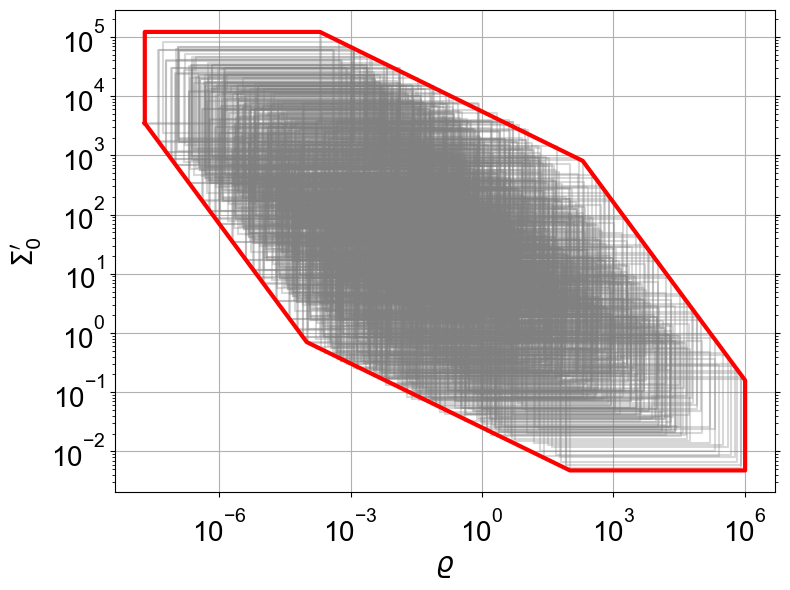

In [11]:
plt.figure(figsize=(8, 6))

for sand_cur in sandstones:
    for i, V_cur in enumerate([1e-3, 1e-2, 1e-1, 1]):
        for mu_cur in np.linspace(1, 5, 5) * 1e-3:
            for K_Ic_cur in np.linspace(0.5, 2, 4) * 1e6:
                sandstone_params = {
                    'E': sand_cur[0], 'nu': sand_cur[1], 'K_Ic': K_Ic_cur, 
                    'alpha': sand_cur[2], 'M': sand_cur[3],
                    'mu': mu_cur, 'V': V_cur, 
                    'sigma_0_p': np.array([1, 35]) * 1e6, 
                    'perm': np.logspace(-1, 3, 5) * 9.869233e-16
                } 

                sandstone_params = add_derived_parameters(sandstone_params)

                x_min, x_max = np.min(sandstone_params['rho']), np.max(sandstone_params['rho'])
                y_min, y_max = np.min(sandstone_params['Sigma_0_p']), np.max(sandstone_params['Sigma_0_p'])

                plt.plot([x_min, x_max, x_max, x_min, x_min], 
                         [y_min, y_min, y_max, y_max, y_min], 
                         color='grey', alpha=0.3)

                mask = (
                    (rho_range_fl >= x_min) & (rho_range_fl <= x_max) & 
                    (Sigma_0_p_range_fl >= y_min) & (Sigma_0_p_range_fl <= y_max)
                )

                indices = np.where(mask)[0]

                for idx in indices:
                    l_mk_rocks[idx].append(sandstone_params['l_mk'])

x_poly = [
    2.0118795316264266e-08,
    2.0118795316264266e-08,
    0.00020118793899880137,
    199.9999966607556,
    1020369.2060743539,
    1020369.2060743539,
    102.03692503913813,
    9.99999999946556e-05,
    2.0118795316264266e-08,
]

y_poly = [
    3498.1927991301304,
    121364.69501624948,
    121364.69501624948,
    807.2544626192414,
    0.1588178175342754,
    0.004779738863105852,
    0.004779738863105852,
    0.7023550833723323,
    3498.1927991301304,
]

plt.plot(x_poly, y_poly, color='red', linestyle='-', linewidth=3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"$\varrho$", fontsize=20)
plt.ylabel(r"$\Sigma_0'$", fontsize=20)

plt.grid()

plt.show()

## Granites

In [12]:
# Columns: E [Pa], nu [-], alpha [-], M [Pa] (Table 2).
# The varied parameter ranges follow Table 3.

granites = np.array([
    [4.83e10, 0.27, 0.27, 5.29e10], # Charcoal 
    [3.75e10, 0.25, 0.47, 5.92e10], # Westerly
    [4.37e10, 0.22, 0.56, 6.14e10], # Sierra White 
    [7.00e10, 0.21, 0.3, 1.46e11], # Lac du Bonnet
    [6.60e10, 0.16, 0.44, 7.94e10], # Stanstead 
    [4.05e10, 0.25, 0.54, 8.15e10], # Grimsel
    [5.39e10, 0.19, 0.35, 1.14e11], # Aue
    [3e10, 0.25, 0.65, 6.11e10], # Barre
    [1.95e10, 0.25, 0.75, 6.97e10] # Chelmsford
])

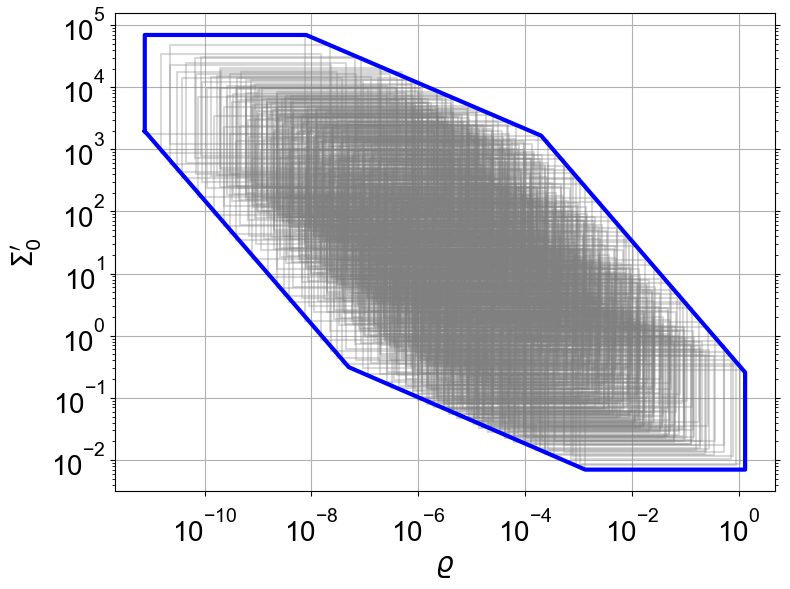

In [13]:
plt.figure(figsize=(8, 6))

for gran_cur in granites:
    for i, V_cur in enumerate([1e-3, 1e-2, 1e-1, 1]):
        for mu_cur in np.linspace(1, 5, 5) * 1e-3:
            for K_Ic_cur in np.linspace(1.5, 3, 4) * 1e6:
                granite_params = {
                    'E': gran_cur[0], 'nu': gran_cur[1], 'K_Ic': K_Ic_cur, 
                    'alpha': gran_cur[2], 'M': gran_cur[3],
                    'mu': mu_cur, 'V': V_cur, 
                    'sigma_0_p': np.array([1, 40]) * 1e6, 
                    'perm': np.logspace(-5, -2, 4) * 9.869233e-16
                }

                granite_params = add_derived_parameters(granite_params)
                
                x_min, x_max = np.min(granite_params['rho']), np.max(granite_params['rho'])
                y_min, y_max = np.min(granite_params['Sigma_0_p']), np.max(granite_params['Sigma_0_p'])

                plt.plot([x_min, x_max, x_max, x_min, x_min], 
                         [y_min, y_min, y_max, y_max, y_min], 
                         color='grey', alpha=0.3)
                
                mask = (
                    (rho_range_fl >= x_min) & (rho_range_fl <= x_max) &
                    (Sigma_0_p_range_fl >= y_min) & (Sigma_0_p_range_fl <= y_max)
                )

                indices = np.where(mask)[0]

                for idx in indices:
                    l_mk_rocks[idx].append(granite_params['l_mk'])

x_poly = [
    7.589882294620831e-12,
    7.589882294620831e-12,
    7.972950150833576e-09,
    0.00019930689510963589,
    1.3137001102731662,
    1.3137001102731662,
    0.0013323187412816063,
    4.998322097139712e-08,
    7.589882294620831e-12,
]

y_poly = [
    1962.2232409561009,
    69341.71597633135,
    69341.71597633135,
    1660.929216180022,
    0.2568237874479716,
    0.006992944974489796,
    0.006992944974489796,
    0.3116098294021143,
    1962.2232409561009,
]

plt.plot(x_poly, y_poly, color='blue', linestyle='-', linewidth=3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"$\varrho$", fontsize=20)
plt.ylabel(r"$\Sigma_0'$", fontsize=20)

plt.grid()

plt.show()

## Shales

In [14]:
# Columns: E [Pa], nu [-], alpha [-], M [Pa] (Table 2).
# The varied parameter ranges follow Table 3.

shales = np.array([
    [3.24e9, 0.3, 0.7, 6.64e9], # Opalinus 
    [1.92e10, 0.18, 0.8, 1.24e10], # Eau Claire 
    [3.60e9, 0.3, 0.86, 7.90e9], # Callovo-Oxfordian
    [1.45e10, 0.26, 0.78, 4.40e10], # Bakken
    [2.40e10, 0.25, 0.6, 5.16e10], # Mancos 
    [2.64e10, 0.21, 0.65, 4.96e10], # Marcellus
])

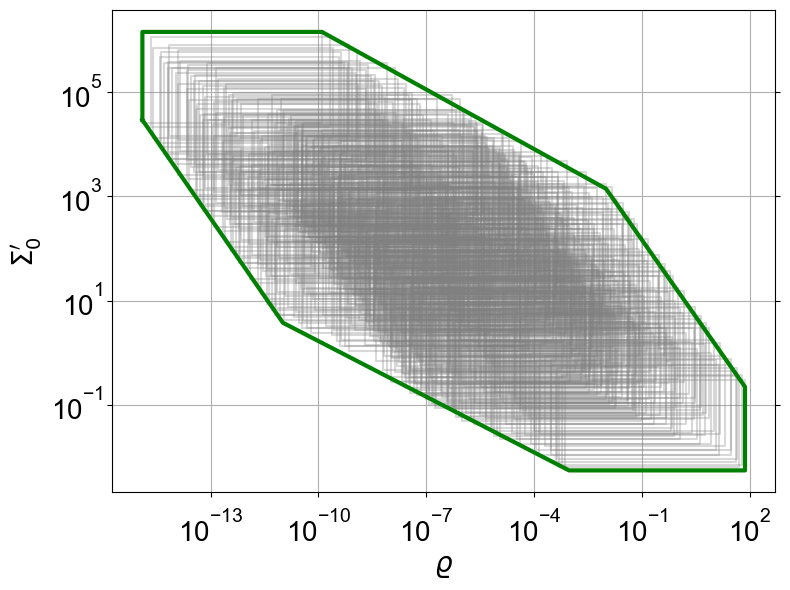

In [15]:
plt.figure(figsize=(8, 6))

for shale_cur in shales:
    for i, V_cur in enumerate([1e-3, 1e-2, 1e-1, 1]):
        for mu_cur in np.linspace(1, 5, 5) * 1e-3:
            for K_Ic_cur in np.linspace(0.5, 2, 4) * 1e6:
                shale_params = {
                    'E': shale_cur[0], 'nu': shale_cur[1], 'K_Ic': K_Ic_cur, 
                    'alpha': shale_cur[2], 'M': shale_cur[3],
                    'mu': mu_cur, 'V': V_cur, 
                    'sigma_0_p': np.array([1, 55]) * 1e6, 
                    'perm': np.logspace(-6, -1, 6) * 9.869233e-16
                }

                shale_params = add_derived_parameters(shale_params)
                
                x_min, x_max = np.min(shale_params['rho']), np.max(shale_params['rho'])
                y_min, y_max = np.min(shale_params['Sigma_0_p']), np.max(shale_params['Sigma_0_p'])

                plt.plot([x_min, x_max, x_max, x_min, x_min], 
                         [y_min, y_min, y_max, y_max, y_min], 
                         color='grey', alpha=0.3)
                
                mask = (
                    (rho_range_fl >= x_min) & (rho_range_fl <= x_max) &
                    (Sigma_0_p_range_fl >= y_min) & (Sigma_0_p_range_fl <= y_max)
                )

                indices = np.where(mask)[0]

                for idx in indices:
                    l_mk_rocks[idx].append(shale_params['l_mk'])

x_poly = [
    1.2705273249782805e-15,
    1.2705273249782805e-15,
    1.255861039408311e-10,
    0.010002383555193449,
    73.07237095159584,
    73.07237095159584,
    0.000933243911664338,
    1.0252060084157682e-11,
    1.2705273249782805e-15,
]

y_poly = [
    29459.623595395537,
    1446219.4533353657,
    1446219.4533353657,
    1400.3635864145997,
    0.21982256544113,
    0.005462680844907409,
    0.005462680844907409,
    3.7532220208548908,
    29459.623595395537,
]

plt.plot(x_poly, y_poly, color='green', linestyle='-', linewidth=3)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"$\varrho$", fontsize=20)
plt.ylabel(r"$\Sigma_0'$", fontsize=20)

plt.grid()

plt.show()

## Comparison of different rock types

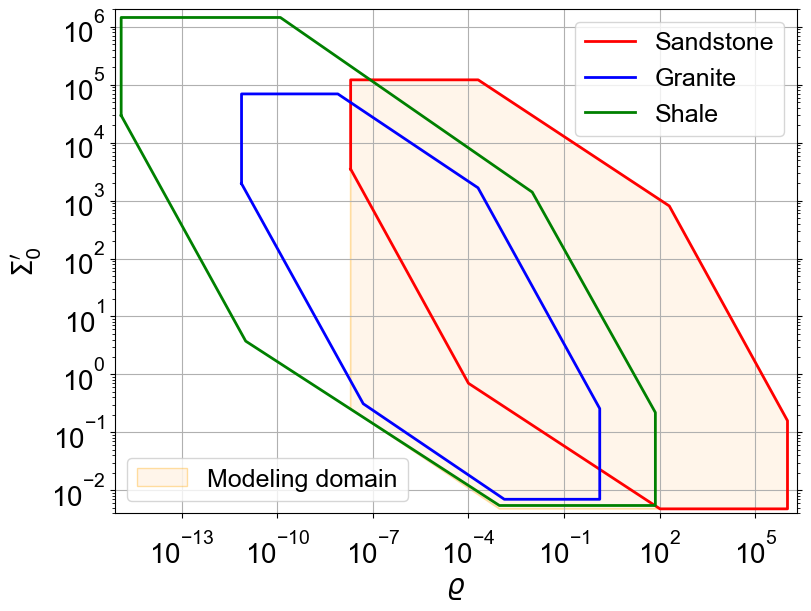

In [16]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# --------------------------------------------------------------------------------------------------
# sandstones
# --------------------------------------------------------------------------------------------------

x_poly = [
    2.0118795316264266e-08,
    2.0118795316264266e-08,
    0.00020118793899880137,
    199.9999966607556,
    1020369.2060743539,
    1020369.2060743539,
    102.03692503913813,
    9.99999999946556e-05,
    2.0118795316264266e-08,
]

y_poly = [
    3498.1927991301304,
    121364.69501624948,
    121364.69501624948,
    807.2544626192414,
    0.1588178175342754,
    0.004779738863105852,
    0.004779738863105852,
    0.7023550833723323,
    3498.1927991301304,
]

plt.plot(x_poly, y_poly, color='red', linestyle='-', linewidth=2, label='Sandstone', zorder=3)

# --------------------------------------------------------------------------------------------------
# granites
# --------------------------------------------------------------------------------------------------

x_poly = [
    7.589882294620831e-12,
    7.589882294620831e-12,
    7.972950150833576e-09,
    0.00019930689510963589,
    1.3137001102731662,
    1.3137001102731662,
    0.0013323187412816063,
    4.998322097139712e-08,
    7.589882294620831e-12,
]

y_poly = [
    1962.2232409561009,
    69341.71597633135,
    69341.71597633135,
    1660.929216180022,
    0.2568237874479716,
    0.006992944974489796,
    0.006992944974489796,
    0.3116098294021143,
    1962.2232409561009,
]

plt.plot(x_poly, y_poly, color='blue', linestyle='-', linewidth=2, label='Granite', zorder=3)

# --------------------------------------------------------------------------------------------------
# shales
# --------------------------------------------------------------------------------------------------

x_poly = [
    1.2705273249782805e-15,
    1.2705273249782805e-15,
    1.255861039408311e-10,
    0.010002383555193449,
    73.07237095159584,
    73.07237095159584,
    0.000933243911664338,
    1.0252060084157682e-11,
    1.2705273249782805e-15,
]

y_poly = [
    29459.623595395537,
    1446219.4533353657,
    1446219.4533353657,
    1400.3635864145997,
    0.21982256544113,
    0.005462680844907409,
    0.005462680844907409,
    3.7532220208548908,
    29459.623595395537,
]

plt.plot(x_poly, y_poly, color='green', linestyle='-', linewidth=2, label='Shale', zorder=3)

# --------------------------------------------------------------------------------------------------
# modeling domain
# --------------------------------------------------------------------------------------------------

plt.fill(
    x_poly_model, y_poly_model,
    facecolor='bisque',
    edgecolor='orange',
    linewidth=1.2,
    alpha=0.35,
    zorder=1
)

# --------------------------------------------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

rock_handles = []
rock_labels = []

for h, lab in zip(handles, labels):
    if lab in ['Sandstone', 'Granite', 'Shale']:
        rock_handles.append(h)
        rock_labels.append(lab)

legend_rocks = ax.legend(
    rock_handles,
    rock_labels,
    loc='upper right',
    fontsize=18,
    frameon=True
)

ax.add_artist(legend_rocks)

# --------------------------------------------------------------------------------------------------
# Second legend: modelling domain
# --------------------------------------------------------------------------------------------------

domain_patch = mpatches.Patch(
    facecolor='bisque',
    edgecolor='orange',
    alpha=0.35,
    label='Modeling domain'
)

legend_domain = ax.legend(
    handles=[domain_patch],
    loc='lower left',
    fontsize=18,
    frameon=True
)

ax.set_xlim(8e-16, 2e6)
ax.set_ylim(4e-3, 2e6)

ax.set_xscale('log')
ax.set_yscale('log')

plt.xlabel(r"$\varrho$", fontsize=20)
plt.ylabel(r"$\Sigma_0'$", fontsize=20)

plt.grid()

plt.show()

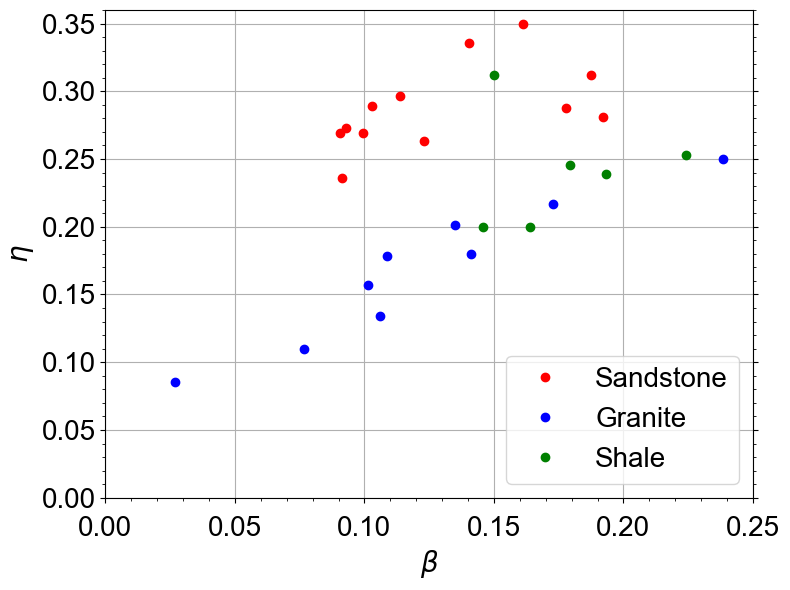

In [17]:
plt.figure(figsize=(8,6))

for sand_cur in sandstones:
    sandstone_params = {
        'E': sand_cur[0], 'nu': sand_cur[1], 'K_Ic': 1e6, 
        'alpha': sand_cur[2], 'M': sand_cur[3],
        'mu': 5e-3, 'V': 0.01, 
        'sigma_0_p': 10e6, 
        'perm': 1 * 9.869233e-16
    }

    sandstone_params = add_derived_parameters(sandstone_params)

    plt.plot(sandstone_params['beta'], sandstone_params['eta'], color='red', marker='o')

for gran_cur in granites:
    granite_params = {
        'E': gran_cur[0], 'nu': gran_cur[1], 'K_Ic': 1e6, 
        'alpha': gran_cur[2], 'M': gran_cur[3],
        'mu': 5e-3, 'V': 0.01, 
        'sigma_0_p': 10e6, 
        'perm': 1 * 9.869233e-16
    }

    granite_params = add_derived_parameters(granite_params)

    plt.plot(granite_params['beta'], granite_params['eta'], color='blue', marker='o')

for shale_cur in shales:
    shale_params = {
        'E': shale_cur[0], 'nu': shale_cur[1], 'K_Ic': 1e6, 
        'alpha': shale_cur[2], 'M': shale_cur[3],
        'mu': 5e-3, 'V': 0.01, 
        'sigma_0_p': 10e6, 
        'perm': 1 * 9.869233e-16
    }

    shale_params = add_derived_parameters(shale_params)

    plt.plot(shale_params['beta'], shale_params['eta'], color='green', marker='o')

plt.xlim(0, 0.25)
plt.ylim(0, 0.36)

plt.xlabel(r'$\beta$', fontsize=20)
plt.ylabel(r'$\eta$', fontsize=20)

plt.grid(True)

plt.plot([], [], 'o', color='red', label='Sandstone')
plt.plot([], [], 'o', color='blue', label='Granite')
plt.plot([], [], 'o', color='green', label='Shale')

plt.legend(fontsize=20, loc='best')

plt.show()

## $\ell_{mk}(\varrho, \Sigma_0')$ (Figure S3)

In [18]:
x = rho_range_fl
y = Sigma_0_p_range_fl

# -----------------------------------------------------------

l_mk_rocks_mean = []
l_mk_rocks_min = []
l_mk_rocks_max = []

for l_mk_list_cur in l_mk_rocks:
    if len(l_mk_list_cur) > 0:
        l_mk_rocks_mean.append(np.mean(l_mk_list_cur))
        l_mk_rocks_min.append(np.min(l_mk_list_cur))
        l_mk_rocks_max.append(np.max(l_mk_list_cur))
    else:
        l_mk_rocks_mean.append(np.nan)
        l_mk_rocks_min.append(np.nan)
        l_mk_rocks_max.append(np.nan)

# -----------------------------------------------------------

l_mk_rocks_mean = np.array(l_mk_rocks_mean)

z = l_mk_rocks_mean

mask = ~np.isnan(z)

l_mk_rocks_mean = griddata(
    (np.log10(x[mask]), np.log10(y[mask])),
    z[mask],
    (np.log10(x), np.log10(y)),
    method='nearest'
)

# -----------------------------------------------------------

l_mk_rocks_min = np.array(l_mk_rocks_min)

z = l_mk_rocks_min

mask = ~np.isnan(z)

l_mk_rocks_min = griddata(
    (np.log10(x[mask]), np.log10(y[mask])),
    z[mask],
    (np.log10(x), np.log10(y)),
    method='nearest'
)

# -----------------------------------------------------------

l_mk_rocks_max = np.array(l_mk_rocks_max)

z = l_mk_rocks_max

mask = ~np.isnan(z)

l_mk_rocks_max = griddata(
    (np.log10(x[mask]), np.log10(y[mask])),
    z[mask],
    (np.log10(x), np.log10(y)),
    method='nearest'
)

C:\Users\kanal\anaconda3\envs\gc_fracture_tip\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


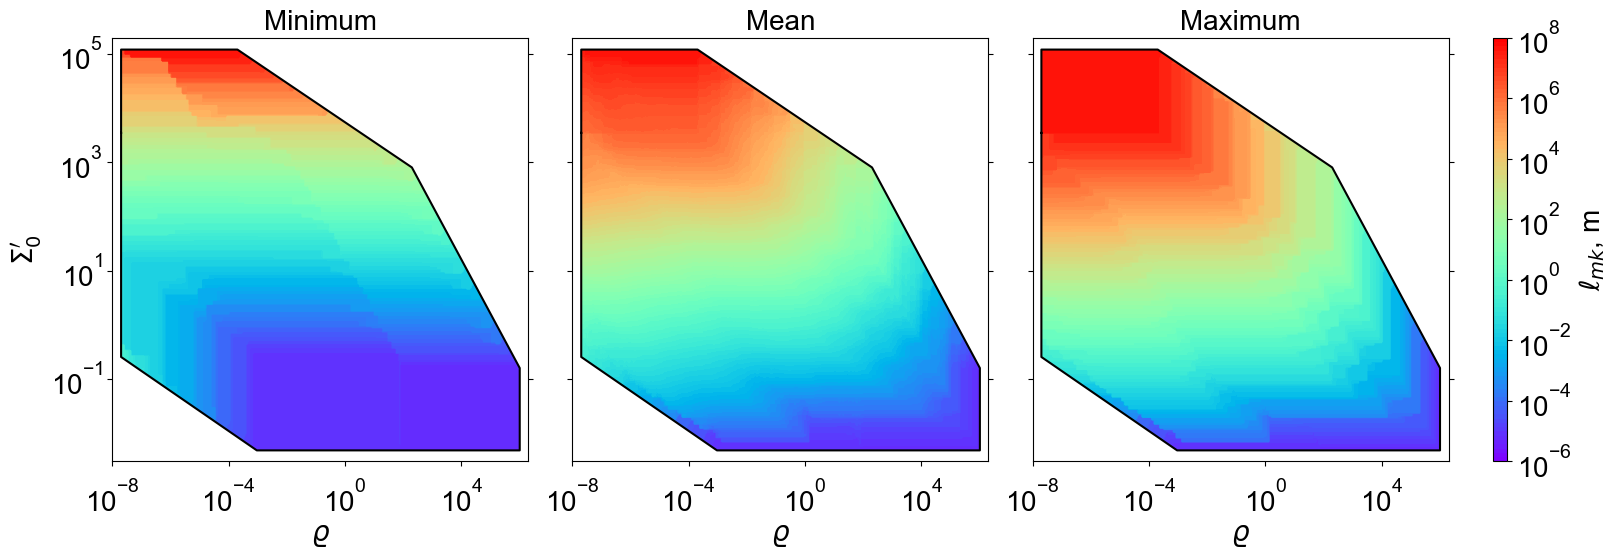

In [19]:
fig = plt.figure(figsize=(18, 5.5))

gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1, 1, 1, 0.035],
    wspace=0.14
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2])
]

axes[1].sharex(axes[0])
axes[2].sharex(axes[0])

axes[1].sharey(axes[0])
axes[2].sharey(axes[0])

cax = fig.add_subplot(gs[0, 3])

XI, YI = rho_range_grid, Sigma_0_p_range_grid

poly = Path_plt(
    np.column_stack((
        np.log10(x_poly_model),
        np.log10(y_poly_model)
    ))
)

points = np.column_stack((
    np.log10(XI.ravel()),
    np.log10(YI.ravel())
))

inside = poly.contains_points(points)
inside_mask = inside.reshape(XI.shape)

vmin, vmax = 1e-6, 1e8

levels = np.logspace(
    np.log10(vmin),
    np.log10(vmax),
    100
)

norm = LogNorm(vmin=vmin, vmax=vmax)

z_values = [
    l_mk_rocks_min,
    l_mk_rocks_mean,
    l_mk_rocks_max
]

titles = [
    'Minimum',
    'Mean',
    'Maximum'
]

for ax, z, title in zip(axes, z_values, titles):
    ZI = z.reshape(XI.shape)
    ZI_masked = np.ma.masked_where(~inside_mask, ZI)

    CS = ax.contourf(
        XI,
        YI,
        ZI_masked,
        levels=levels,
        norm=norm,
        cmap='rainbow'
    )

    ax.plot(
        x_poly_model,
        y_poly_model,
        linestyle='-',
        color='black'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(1e-8, 2e6)
    ax.set_ylim(3e-3, 2e5)

    ax.set_xlabel(r'$\varrho$', fontsize=20)
    ax.set_title(title, fontsize=20)

    ax.tick_params(
        axis='both',
        labelsize=20
    )

# ------------------------------------------------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------------------------------------------------

axes[0].set_ylabel(
    r"$\Sigma_0'$",
    fontsize=20
)

for ax in axes[1:]:
    ax.tick_params(
        axis='y',
        labelleft=False
    )

cbar = fig.colorbar(
    CS,
    cax=cax
)

ticks = np.logspace(
    np.floor(np.log10(vmin)),
    np.ceil(np.log10(vmax)),
    8
)

cbar.set_ticks(ticks)

cbar.ax.yaxis.set_major_formatter(
    ticker.LogFormatterMathtext()
)

cbar.ax.tick_params(
    labelsize=20
)

cbar.set_label(
    r'$\ell_{mk}$, m',
    fontsize=20
)

plt.show()

In [20]:
# The distributions of l_mk(rho, Sigma_0') above use fewer rock-parameter samples.
# Load the precomputed l_mk(rho, Sigma_0') lookup for the subsequent calculations.
data_l_mk = np.load(data_folder / 'l_mk_mean_min_max.npy')
rho_range_l_mk, Sigma_0_p_range_l_mk, l_mk_rocks_mean = data_l_mk[:, 0], data_l_mk[:, 1], data_l_mk[:, 2]

# Solution across the dimensionless parameter space (Section 5.2)

## Effect of the dimensionless permeability $\varrho$ (Section 5.2.1)

We calculate the fracture profiles corresponding to the horizontal transect $\Sigma_0' = 10^{-2}$. 

The input parameters for the remaining horizontal transects, $\Sigma_0' = 10$ and $10^4$, are commented.

In [21]:
## Horizontal transect: Sigma_0' = 1e-2
Sigma_0_p_cur = 1e-2
rho_range = np.array([1e-4, 1, 1e2, 1e4, 1e6])
p_init_param = 5e-3

## Horizontal transect: Sigma_0' = 10
# Sigma_0_p_cur = 10
# rho_range = np.array([1e-8, 1e-2, 1, 1e2, 1e4])
# p_init_param = 5e-3

## Horizontal transect: Sigma_0' = 1e4
# Sigma_0_p_cur = 1e4
# rho_range = np.array([1e-8, 1e-6, 1e-4, 1e-2, 1])
# p_init_param = 3e-3

beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

num_cases = rho_range.shape[0]
sol_save = np.zeros((num_cases, num_points - 1, 4))

for i in range(num_cases):
    model_params = {
        'rho': rho_range[i], 'Sigma_0_p': Sigma_0_p_cur, 
        'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
        'p_init_param': p_init_param,
        'flag_one_way': 1,
        'method': 'hybr'
    }

    solver = Solver(model_params, gc)
    sol_cur = solver.solve(None)

    sol_save[i] = np.concatenate((
        sol_cur['x_z'][:, None], sol_cur['w'][:, None], 
        sol_cur['p'][:, None], sol_cur['v'][:, None]
    ), axis=1)

Solver converged successfully
Residual norm: 7.21e-02
Solver converged successfully
Residual norm: 2.14e-05
Solver converged successfully
Residual norm: 7.08e-07
Solver converged successfully
Residual norm: 1.39e-08
Solver converged successfully
Residual norm: 3.40e-07


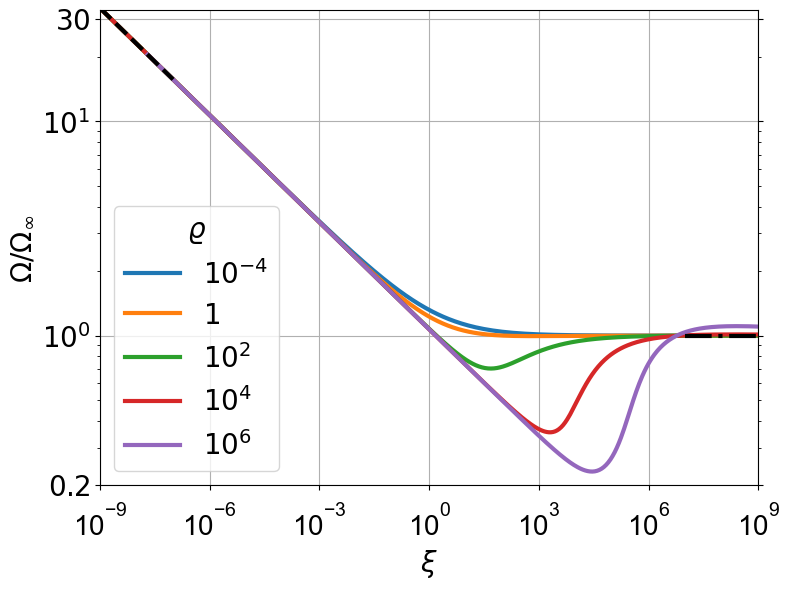

In [22]:
plt.figure(figsize=(8,6))

if Sigma_0_p_cur == 1e-2:
    vals_plot = ['$10^{-4}$', '$1$', '$10^2$', '$10^4$', '$10^6$']
elif Sigma_0_p_cur == 10:
    vals_plot = ['$10^{-8}$', '$10^{-2}$', '$1$', '$10^2$', '$10^4$']
elif Sigma_0_p_cur == 1e4:
    vals_plot = ['$10^{-8}$', '$10^{-6}$', '$10^{-4}$', '$10^{-2}$', '$1$']
    
for i in range(num_cases):
    x_cur, w_cur = sol_save[i, :, 0], sol_save[i, :, 1] 
    coef_cur = far_field_opening(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label=vals_plot[i])

x_range_near = np.geomspace(1e-9, 1e-7, 10)
coef_near = far_field_opening(x_range_near, beta_cur) ** -1 
plt.plot(x_range_near, coef_near * near_field_opening(x_range_near), linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e7, 1e9, 10)
coef_far = far_field_opening(x_range_far, beta_cur) ** -1 
plt.plot(x_range_far, coef_far * far_field_opening(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-9, 1e9)
plt.ylim(0.2, 33)

ax = plt.gca()
ax.set_yticks([0.2, 1, 10, 30])
ax.set_yticklabels([r'$0.2$',r'$10^{0}$', r'$10^{1}$', r'$30$'])

plt.legend(title=r"$\varrho$", loc=3, fontsize=20, title_fontsize=20, ncol=1)

plt.grid()

plt.show()

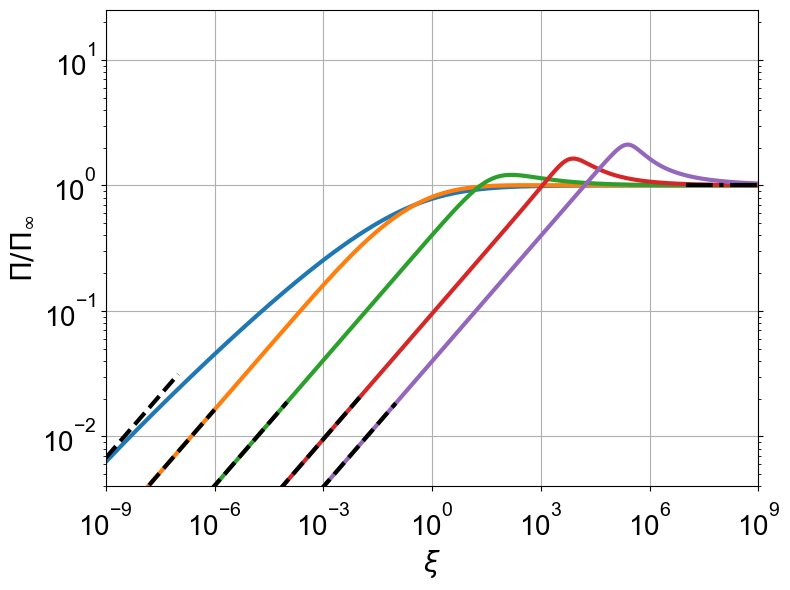

In [23]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, p_cur = sol_save[i, :, 0], sol_save[i, :, 2]
    coef_cur = far_field_pressure(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * p_cur, linewidth=3, label=vals_plot[i])

if Sigma_0_p_cur == 1e-2:
    near_field_right_border = [1e-7, 1e-6, 1e-4, 1e-2, 1e-1]
elif Sigma_0_p_cur == 10:
    near_field_right_border = [1e-9, 1e-9, 1e-7, 1e-7, 1e-7]
elif Sigma_0_p_cur == 1e4:
    near_field_right_border = [1e-9, 1e-9, 1e-7, 1e-7, 1e-7]

for i in range(num_cases):
    x_range_near = np.geomspace(1e-9, near_field_right_border[i], 10)
    coef_near = far_field_pressure(x_range_near, beta_cur) ** -1
    plt.plot(x_range_near, coef_near * np.ones_like(x_range_near) * sol_save[i, -1, 2], 
             linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e7, 1e9, 10)
coef_far = far_field_pressure(x_range_far, beta_cur) ** -1
plt.plot(x_range_far, coef_far * far_field_pressure(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xlim(1e-9, 1e9)
plt.ylim(4e-3, 25)
 
plt.xscale('log')
plt.yscale('log')

plt.grid()

plt.show()

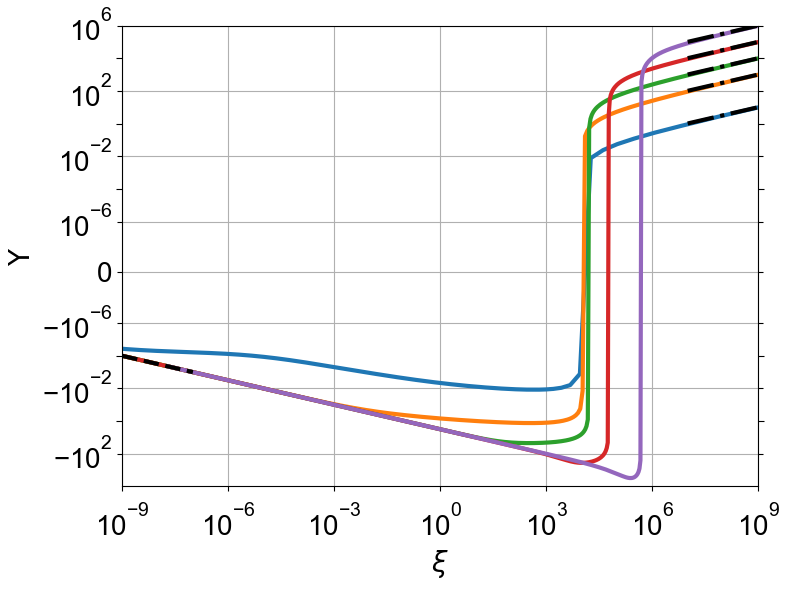

In [24]:
plt.figure(figsize=(8,6))

if Sigma_0_p_cur == 1e-2:
    far_field_left_border = [1e7] * 5
elif Sigma_0_p_cur == 10:
    far_field_left_border = [1e5, 1e7, 1e7, 1e5, 1e3]
elif Sigma_0_p_cur == 1e4:
    far_field_left_border = [1e5, 1e6, 1e5, 1e3, 1e1]

for i in range(num_cases):
    x_cur, v_cur = sol_save[i, :, 0], sol_save[i, :, 3]
    plt.plot(x_cur, v_cur, linewidth=3, label=vals_plot[i])

    x_range_far = np.geomspace(far_field_left_border[i], 1e9, 10)
    plt.plot(x_range_far, far_field_fluid_displacement(x_range_far, rho_range[i], Sigma_0_p_cur, S_cur),
             linestyle='-.', color='black', linewidth=3)

x_range_near = np.logspace(-9, -7, 10)
plt.plot(x_range_near, near_field_fluid_displacement(x_range_near), linestyle='--', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xlim(1e-9, 1e9)
plt.ylim(-1e4, 1e6)

plt.xscale("log")
plt.yscale("symlog", linthresh=1e-8)
y_ticks = np.array([-1e2, -1e-2, -1e-6, 0.0, 1e-6, 1e-2, 1e2, 1e6])

ax = plt.gca()
ax.set_yticks(y_ticks)

minor_ticks = np.array([-1, -1e-4, 1e-4, 1, 1e4])
ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="minor", length=4, width=0.8)

plt.grid()

plt.show()

## Effect of the dimensionless effective confining stress $\Sigma_0'$ (Section 5.2.2)

We calculate the fracture profiles corresponding to the vertical transect $\varrho = 10^{-3}$. 

The input parameters for the remaining vertical transects, $\varrho = 10$ and $10^5$, are commented.

In [25]:
## Vertical transect: rho = 1e-3
rho_cur = 1e-3
Sigma_0_p_range = np.array([1e-2, 1e1, 1e3, 1e5]) 
p_init_param = 5.5e-3

## Vertical transect: rho = 10
# rho_cur = 10
# Sigma_0_p_range = np.array([1e-2, 1e1, 1e2, 1e3])
# p_init_param = 1

## Vertical transect: rho = 1e5
# rho_cur = 1e5
# Sigma_0_p_range = np.array([5e-3, 1e-2, 1e-1, 1e0])
# p_init_param = 1

beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

num_cases = Sigma_0_p_range.shape[0]
sol_save = np.zeros((num_cases, num_points - 1, 4))

for i in range(num_cases):
    model_params = {
        'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_range[i], 
        'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
        'p_init_param': p_init_param,
        'flag_one_way': 1,
        'method': 'hybr'
    }

    solver = Solver(model_params, gc)
    sol_cur = solver.solve(None)

    sol_save[i] = np.concatenate((
        sol_cur['x_z'][:, None], sol_cur['w'][:, None], 
        sol_cur['p'][:, None], sol_cur['v'][:, None]
    ), axis=1)

Solver converged successfully
Residual norm: 1.08e-02
Solver converged successfully
Residual norm: 2.55e-06
Solver converged successfully
Residual norm: 3.94e-10
Solver converged successfully
Residual norm: 4.68e-04


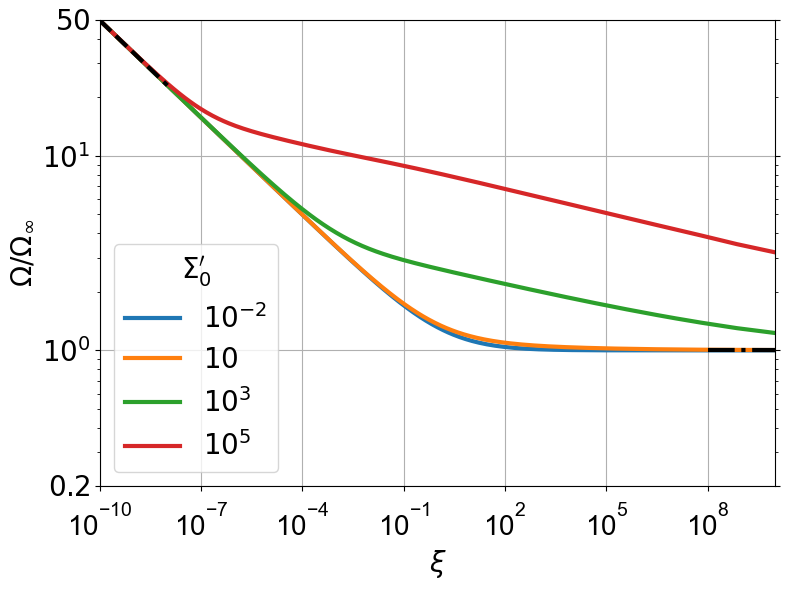

In [26]:
plt.figure(figsize=(8,6))

if rho_cur == 1e-3:
    vals_plot = ['$10^{-2}$', '$10$', '$10^3$', '$10^5$']
elif rho_cur == 10:
    vals_plot = ['$10^{-2}$', '$10$', '$10^2$', '$10^3$']
elif rho_cur == 1e5:
    vals_plot = ['$5 \cdot 10^{-3}$', '$10^{-2}$', '$0.1$', '$1$']
    
for i in range(num_cases):
    x_cur, w_cur = sol_save[i, :, 0], sol_save[i, :, 1] 
    coef_cur = far_field_opening(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label=vals_plot[i])

x_range_near = np.geomspace(1e-10, 1e-8, 10)
coef_near = far_field_opening(x_range_near, beta_cur) ** -1 
plt.plot(x_range_near, coef_near * near_field_opening(x_range_near), linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e8, 1e10, 10)
coef_far = far_field_opening(x_range_far, beta_cur) ** -1 
plt.plot(x_range_far, coef_far * far_field_opening(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-10, 1e10)
plt.ylim(0.2, 50)

ax = plt.gca()
ax.set_yticks([0.2, 1, 10, 50])
ax.set_yticklabels([r'$0.2$',r'$10^{0}$', r'$10^{1}$', r'$50$'])

plt.legend(title=r"$\Sigma_0'$", loc=3, fontsize=20, title_fontsize=20)

plt.grid()

plt.show()

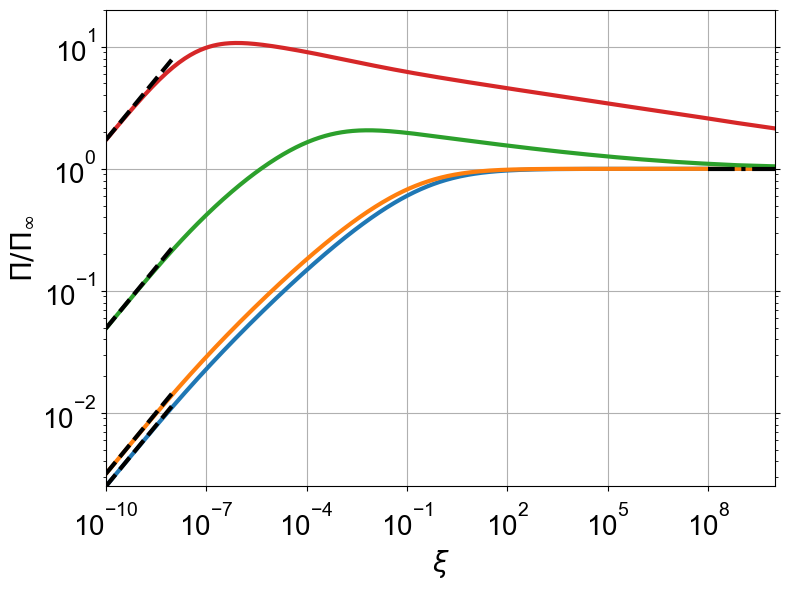

In [27]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, p_cur = sol_save[i, :, 0], sol_save[i, :, 2]
    coef_cur = far_field_pressure(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * p_cur, linewidth=3, label=vals_plot[i])

if rho_cur == 1e-3:
    near_field_right_border = [1e-8] * 5
elif rho_cur == 10:
    near_field_right_border = [1e-6, 1e-8, 1e-8, 1e-8, 1e-8]
elif rho_cur == 1e5:
    near_field_right_border = [1e-2, 1e-2, 1e-4, 1e-5, 1e-5]

for i in range(num_cases):
    x_range_near = np.geomspace(1e-10, near_field_right_border[i], 10)
    coef_near = far_field_pressure(x_range_near, beta_cur) ** -1
    plt.plot(x_range_near, coef_near * np.ones_like(x_range_near) * sol_save[i, -1, 2], 
             linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e8, 1e10, 10)
coef_far = far_field_pressure(x_range_far, beta_cur) ** -1
plt.plot(x_range_far, coef_far * far_field_pressure(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xlim(1e-10, 1e10)
plt.ylim(2.5e-3, 20)
 
plt.xscale('log')
plt.yscale('log')

plt.grid()

plt.show()

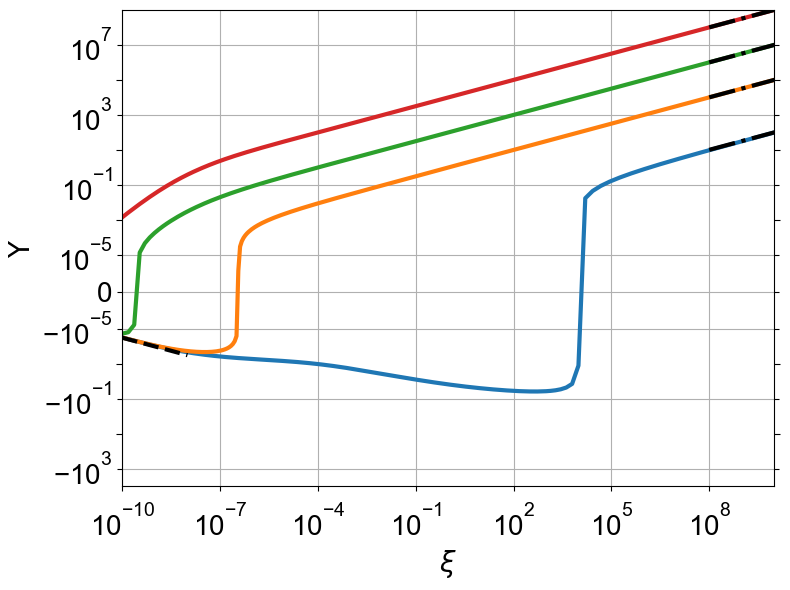

In [28]:
plt.figure(figsize=(8,6))

x_range_far = np.logspace(8, 10, 10)

for i in range(num_cases):
    x_cur, v_cur = sol_save[i, :, 0], sol_save[i, :, 3]
    plt.plot(x_cur, v_cur, linewidth=3, label=vals_plot[i])

    plt.plot(x_range_far, far_field_fluid_displacement(x_range_far, rho_cur, Sigma_0_p_range[i], S_cur), 
            linestyle='-.', color='black', linewidth=3)

x_range_near = np.logspace(-10, -8, 10)
plt.plot(x_range_near, near_field_fluid_displacement(x_range_near), linestyle='--', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xlim(1e-10, 1e10)
plt.ylim(-1e4, 1e9)

plt.xscale("log")
plt.yscale("symlog", linthresh=1e-6)
y_ticks = np.array([-1e3, -1e-1, -1e-5, 0, 1e-5, 1e-1, 1e3, 1e7])

ax = plt.gca()
ax.set_yticks(y_ticks)

minor_ticks = np.array([-1e1, -1e-1, -1e-3, 1e-3, 1e-1, 1e1, 1e5])
ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="minor", length=4, width=0.8)

plt.grid()

plt.show()

## Effect of the fracture propagation velocity $V$ (Section 5.2.3)

In [29]:
rho_Sigma_0_p = 100

rho_range = np.logspace(-3, 3, 7)[::-1]
Sigma_0_p_range = rho_Sigma_0_p / rho_range
p_init_param = 5e-3

beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

num_cases = rho_range.shape[0]
sol_save = np.zeros((num_cases, num_points - 1, 4))

x0 = None

for i in range(num_cases):
    model_params = {
        'rho': rho_range[i], 'Sigma_0_p': Sigma_0_p_range[i], 
        'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
        'p_init_param': p_init_param,
        'flag_one_way': 1,
        'method': 'hybr'
    }

    solver = Solver(model_params, gc)
    sol_cur = solver.solve(x0)

    x0 = sol_cur['sol']

    sol_save[i] = np.concatenate((
        sol_cur['x_z'][:, None], sol_cur['w'][:, None], 
        sol_cur['p'][:, None], sol_cur['v'][:, None]
    ), axis=1)

rho_range_plot = np.array([1e-3, 1e-1, 1e1, 1e3]) 
Sigma_0_p_range_plot = rho_Sigma_0_p / rho_range_plot

idx = np.array([np.argmin(np.abs(rho_range - val)) for val in rho_range_plot])

sol_save = sol_save[idx]

rho_range = np.copy(rho_range_plot)
Sigma_0_p_range = np.copy(Sigma_0_p_range_plot)

num_cases = rho_range.shape[0]

Solver converged successfully
Residual norm: 2.93e-06
Solver converged successfully
Residual norm: 6.75e-07
Solver converged successfully
Residual norm: 4.20e-05
Solver converged successfully
Residual norm: 3.52e-05
Solver converged successfully
Residual norm: 6.16e-05
Solver converged successfully
Residual norm: 3.95e-06
Solver converged successfully
Residual norm: 2.77e-04


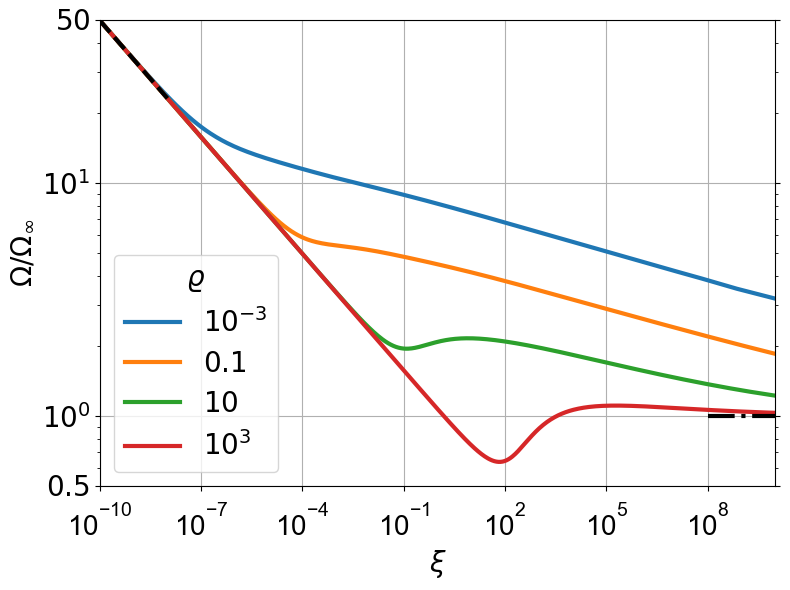

In [30]:
plt.figure(figsize=(8,6))

vals_plot = ['$10^{-3}$', '$0.1$', '$10$', '$10^3$']

for i in range(num_cases):
    x_cur, w_cur = sol_save[i, :, 0], sol_save[i, :, 1] 
    coef_cur = far_field_opening(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label=vals_plot[i])

x_range_near = np.geomspace(1e-10, 1e-8, 10)
coef_near = far_field_opening(x_range_near, beta_cur) ** -1 
plt.plot(x_range_near, coef_near * near_field_opening(x_range_near), linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e8, 1e10, 10)
coef_far = far_field_opening(x_range_far, beta_cur) ** -1 
plt.plot(x_range_far, coef_far * far_field_opening(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-10, 1e10)
plt.ylim(0.5, 50)

ax = plt.gca()
ax.set_yticks([0.5, 1, 10, 50])
ax.set_yticklabels([r'$0.5$',r'$10^{0}$', r'$10^{1}$', r'$50$'])

plt.legend(title=r"$\varrho$", loc=3, fontsize=20, title_fontsize=20, ncol=1)

plt.grid()

plt.show()

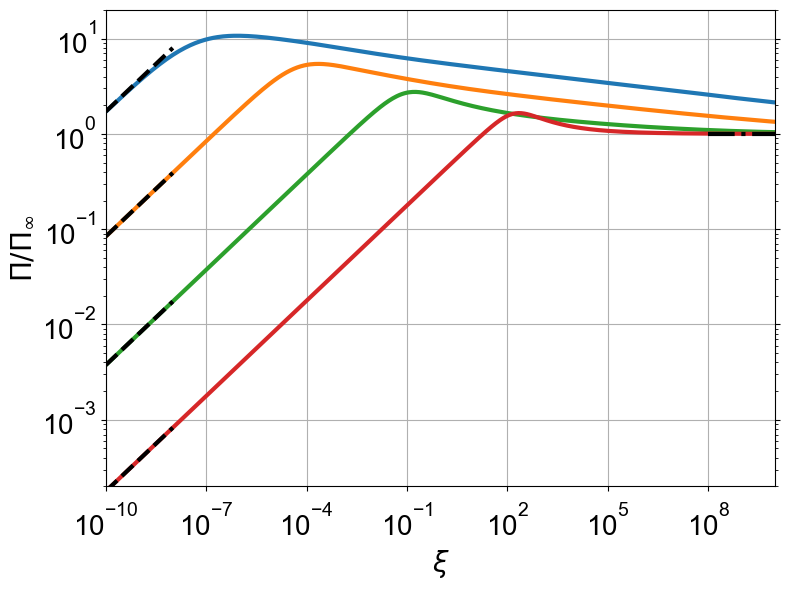

In [31]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, p_cur = sol_save[i, :, 0], sol_save[i, :, 2]
    coef_cur = far_field_pressure(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * p_cur, linewidth=3, label=vals_plot[i])

x_range_near = np.geomspace(1e-10, 1e-8, 10)
for i in range(num_cases):
    coef_near = far_field_pressure(x_range_near, beta_cur) ** -1
    plt.plot(x_range_near, coef_near * np.ones_like(x_range_near) * sol_save[i, -1, 2], 
             linestyle='--', color='black', linewidth=3)

x_range_far = np.geomspace(1e8, 1e10, 10)
coef_far = far_field_pressure(x_range_far, beta_cur) ** -1
plt.plot(x_range_far, coef_far * far_field_pressure(x_range_far, beta_cur), linestyle='-.', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xlim(1e-10, 1e10)
plt.ylim(2e-4, 20)
 
plt.xscale('log')
plt.yscale('log')

plt.grid()

plt.show()

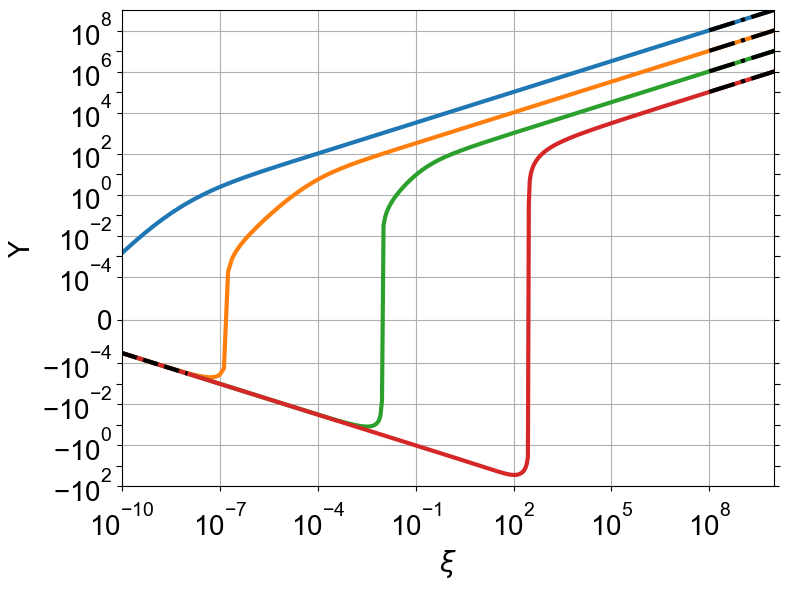

In [32]:
plt.figure(figsize=(8,6))

x_range_far = np.logspace(8, 10, 10)

for i in range(num_cases):
    x_cur, v_cur = sol_save[i, :, 0], sol_save[i, :, 3]
    plt.plot(x_cur, v_cur, linewidth=3, label=vals_plot[i])

    plt.plot(x_range_far, far_field_fluid_displacement(x_range_far, rho_range[i], Sigma_0_p_range[i], S_cur), 
            linestyle='-.', color='black', linewidth=3)

x_range_near = np.logspace(-10, -8, 10)
plt.plot(x_range_near, near_field_fluid_displacement(x_range_near), linestyle='--', color='black', linewidth=3)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xlim(1e-10, 1e10)
plt.ylim(-1e2, 1e9)

plt.xscale("log")
plt.yscale("symlog", linthresh=1e-5)
y_ticks = np.array([-1e2, -1e0, -1e-2, -1e-4, 0, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8])

ax = plt.gca()
ax.set_yticks(y_ticks)

minor_ticks = np.array([-1e1, -1e-1, -1e-3, 1e-3, 1e-1, 1e1, 1e5, 1e7])
ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="y", which="minor", length=4, width=0.8)

plt.grid()

plt.show()

## Effect of the dimensionless parameter $\beta$ (Appendix D.1)

We calculate the fracture profiles corresponding to the point $(\varrho, \Sigma_0') = (10^{-5}, 10^2)$. 

The input parameters for the two points, $(\varrho, \Sigma_0') = (10^3, 10)$ and $(\varrho, \Sigma_0') = (10^4, 10^{-2})$, are commented.

In [33]:
beta_range = np.array([0.03, 0.1 , 0.17, 0.24])
eta_cur = 0.3
S_range = 2 * (1 - beta_range) * eta_cur ** 2 / beta_range

## Point 1
rho_cur = 1e-5
Sigma_0_p_cur = 1e2

## Point 2
# rho_cur = 1e3
# Sigma_0_p_cur = 10

## Point 3
# rho_cur = 1e4
# Sigma_0_p_cur = 1e-2

num_cases = beta_range.shape[0]
sol_save = np.zeros((num_cases, num_points - 1, 4))

for i in range(num_cases):
    model_params = {
        'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
        'beta': beta_range[i], 'eta': eta_cur, 'S': S_range[i],
        'p_init_param': 5e-3,
        'flag_one_way': 1,
        'method': 'hybr'
    }

    solver = Solver(model_params, gc)
    sol_cur = solver.solve(None)

    sol_save[i] = np.concatenate((
        sol_cur['x_z'][:, None], sol_cur['w'][:, None], 
        sol_cur['p'][:, None], sol_cur['v'][:, None]
    ), axis=1)

Solver converged successfully
Residual norm: 5.04e-09
Solver converged successfully
Residual norm: 1.36e-04
Solver converged successfully
Residual norm: 1.24e-04
Solver converged successfully
Residual norm: 5.21e-05


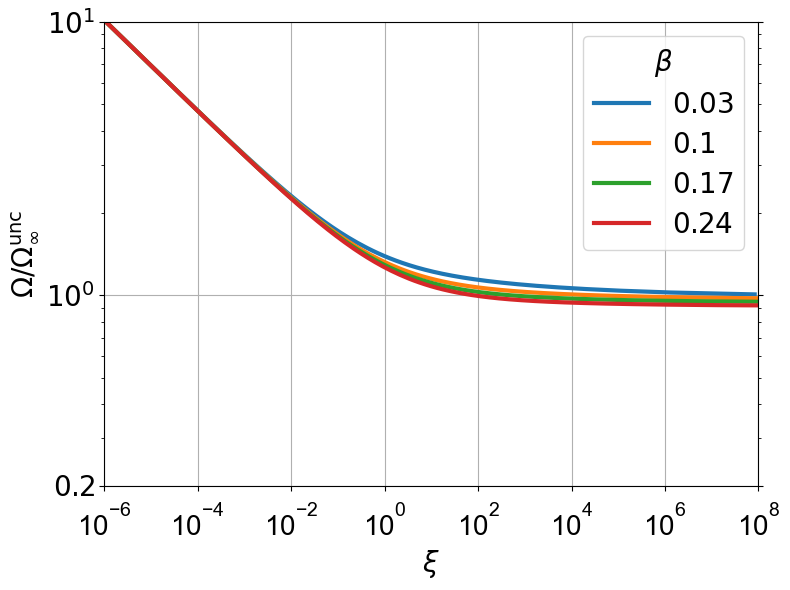

In [34]:
plt.figure(figsize=(8,6))

vals_plot = ['$0.03$', '$0.1$', '$0.17$', '$0.24$']
  
for i in range(num_cases):
    x_cur, w_cur = sol_save[i, :, 0], sol_save[i, :, 1] 
    coef_cur = far_field_opening(x_cur, 0) ** -1
    plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label=vals_plot[i])

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}^{\mathrm{unc}}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-6, 1e8)
plt.ylim(0.2, 10)

ax = plt.gca()
ax.set_yticks([0.2, 1, 10])
ax.set_yticklabels([r'$0.2$',r'$10^{0}$', r'$10^{1}$'])

plt.legend(title=r'$\beta$', fontsize=20, title_fontsize=20)

plt.grid()

plt.show()

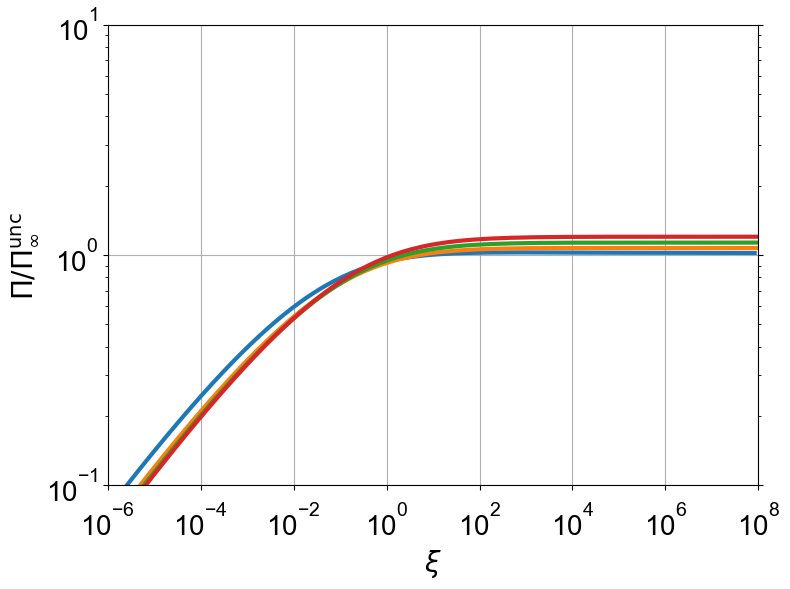

In [35]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, p_cur = sol_save[i, :, 0], sol_save[i, :, 2]
    coef_cur = far_field_pressure(x_cur, 0) ** -1
    plt.plot(x_cur, coef_cur * p_cur, linewidth=3, label=vals_plot[i])

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}^{\mathrm{unc}}$', fontsize=20)

plt.xlim(1e-6, 1e8)
plt.ylim(0.1, 10)
 
plt.xscale('log')
plt.yscale('log')

plt.grid()

plt.show()

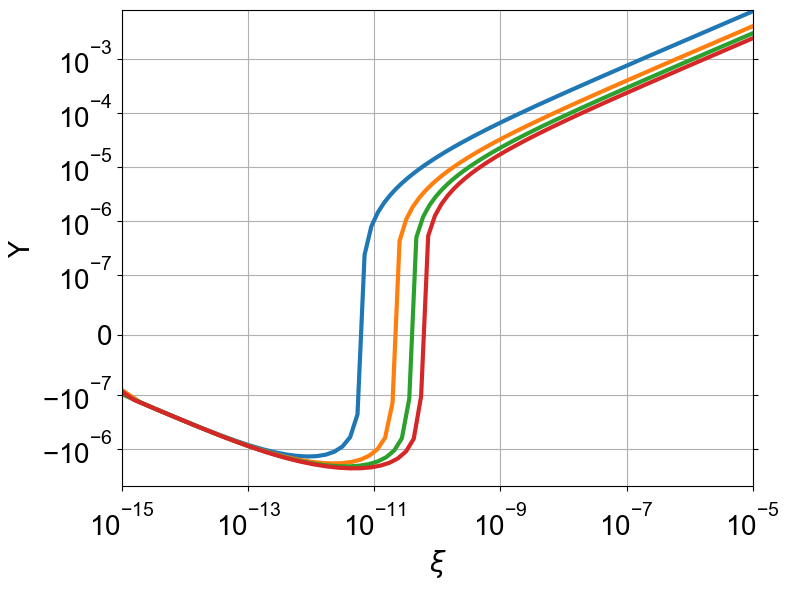

In [36]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, v_cur = sol_save[i, :, 0], sol_save[i, :, 3]
    plt.plot(x_cur, v_cur, linewidth=3, label=vals_plot[i])


plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xscale("log")

if rho_cur == 1e-5:
    plt.xlim(1e-15, 1e-5)
    plt.ylim(-5e-6, 8e-3)
    plt.yscale("symlog", linthresh=1e-7)
elif rho_cur == 1e3:
    plt.xlim(1e-3, 1e4)
    plt.ylim(-5, 3e5)
    plt.yscale("symlog", linthresh=1e-2)
elif rho_cur == 1e4:
    plt.xlim(1e2, 1e9)
    plt.ylim(-3e3, 3e5)
    plt.yscale("symlog", linthresh=1e0)

plt.grid()

plt.show()

## Effect of the poroelastic stress coefficient $\eta$ (Appendix D.2)

We calculate the fracture profiles corresponding to the point $(\varrho, \Sigma_0') = (10^{-5}, 10^2)$. 

The input parameters for the two points, $(\varrho, \Sigma_0') = (10^3, 10)$ and $(\varrho, \Sigma_0') = (10^4, 10^{-2})$, are commented.

In [37]:
eta_range = np.array([0.09, 0.18, 0.26, 0.35])
beta_cur = 0.15
S_range = 2 * (1 - beta_cur) * eta_range ** 2 / beta_cur

## Point 1
rho_cur = 1e-5
Sigma_0_p_cur = 1e2

## Point 2
# rho_cur = 1e3
# Sigma_0_p_cur = 10

## Point 3
# rho_cur = 1e4
# Sigma_0_p_cur = 1e-2

num_cases = eta_range.shape[0]
sol_save = np.zeros((num_cases, num_points - 1, 4))

for i in range(num_cases):
    model_params = {
        'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
        'beta': beta_cur, 'eta': eta_range[i], 'S': S_range[i],
        'p_init_param': 5e-3,
        'flag_one_way': 1,
        'method': 'hybr'
    }

    solver = Solver(model_params, gc)
    sol_cur = solver.solve(None)

    sol_save[i] = np.concatenate((
        sol_cur['x_z'][:, None], sol_cur['w'][:, None], 
        sol_cur['p'][:, None], sol_cur['v'][:, None]
    ), axis=1)

Solver converged successfully
Residual norm: 1.71e-06
Solver converged successfully
Residual norm: 3.64e-05
Solver converged successfully
Residual norm: 6.70e-05
Solver converged successfully
Residual norm: 1.19e-04


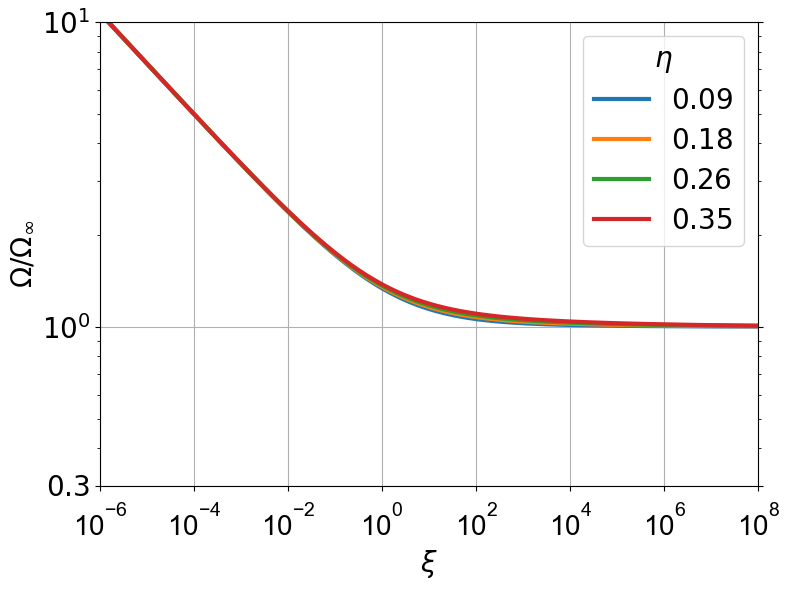

In [38]:
plt.figure(figsize=(8,6))

vals_plot = ['$0.09$', '$0.18$', '$0.26$', '$0.35$']
  
for i in range(num_cases):
    x_cur, w_cur = sol_save[i, :, 0], sol_save[i, :, 1] 
    coef_cur = far_field_opening(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label=vals_plot[i])

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-6, 1e8)
plt.ylim(0.3, 10)

ax = plt.gca()
ax.set_yticks([0.3, 1, 10])
ax.set_yticklabels([r'$0.3$',r'$10^{0}$', r'$10^{1}$'])

plt.legend(title=r'$\eta$', fontsize=20, title_fontsize=20)

plt.grid()

plt.show()

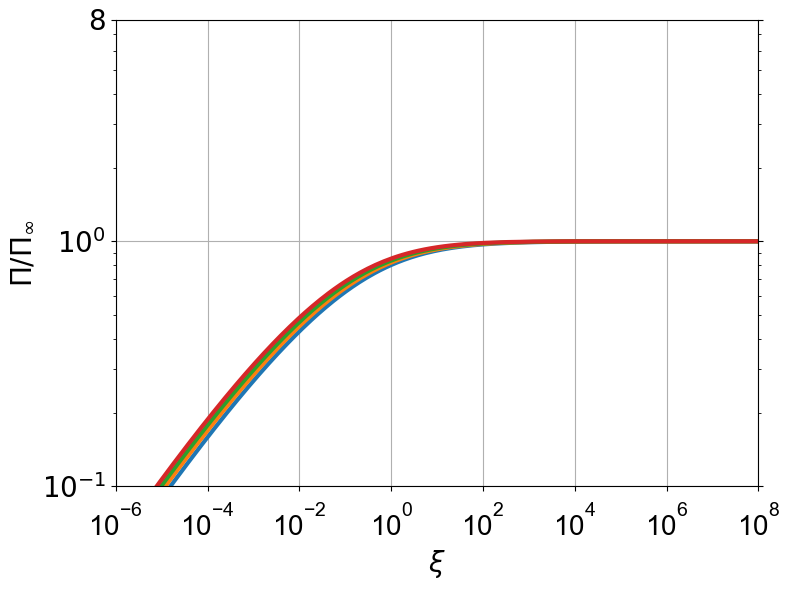

In [39]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, p_cur = sol_save[i, :, 0], sol_save[i, :, 2]
    coef_cur = far_field_pressure(x_cur, beta_cur) ** -1
    plt.plot(x_cur, coef_cur * p_cur, linewidth=3, label=vals_plot[i])

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xlim(1e-6, 1e8)
plt.ylim(0.1, 8)

plt.xscale('log')
plt.yscale('log')

ax = plt.gca()
ax.set_yticks([0.1, 1, 8])
ax.set_yticklabels([r'$10^{-1}$',r'$10^{0}$',r'$8$'])

plt.grid()

plt.show()

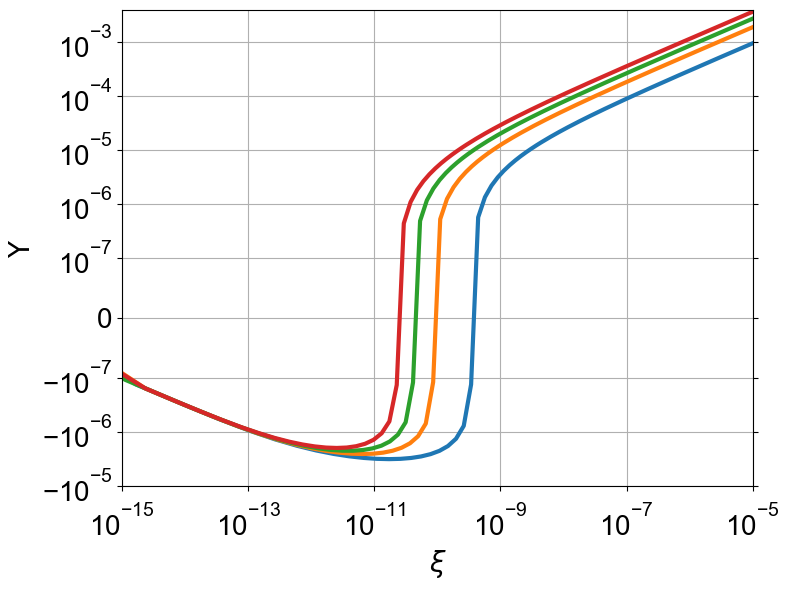

In [40]:
plt.figure(figsize=(8,6))

for i in range(num_cases):
    x_cur, v_cur = sol_save[i, :, 0], sol_save[i, :, 3]
    plt.plot(x_cur, v_cur, linewidth=3, label=vals_plot[i])

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xscale("log")

if rho_cur == 1e-5:
    plt.xlim(1e-15, 1e-5)
    plt.ylim(-1e-5, 4e-3)
    plt.yscale("symlog", linthresh=1e-7)
elif rho_cur == 1e3:
    plt.xlim(1e-3, 1e4)
    plt.ylim(-5, 1e5)
    plt.yscale("symlog", linthresh=1e-1)
elif rho_cur == 1e4:
    plt.xlim(1e2, 1e9)
    plt.ylim(-1e3, 1e5)
    plt.yscale("symlog", linthresh=1)

plt.grid()

plt.show()

# Relative importance of the poroelastic coupling mechanisms (Section 5.3)

## Calculation inside the modeling domain

In [41]:
beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

In [42]:
num_Sigma_0_p = 30
Sigma_0_p_range = np.geomspace(0.004779738863105852, 121364.69501624948, num_Sigma_0_p)

lower_right_func = lambda x: 10 ** 5.20703747 * x ** -0.99956412
upper_right_func = lambda x: 10 ** 3.7422903 * x ** -0.36300259
lower_left_func = lambda x: 0.0003621885086857019 * x ** -0.3697913250816009

point_right = root_scalar(lambda x: upper_right_func(x) - lower_right_func(x), \
                        bracket=[1e-9, 1e7], method='brentq').root
point_left = 2.0118795316264266e-08

def rho_lower_func(Sigma_0_p):
    if Sigma_0_p < lower_left_func(point_left):
        point = root_scalar(lambda x: lower_left_func(x) - Sigma_0_p, 
                            bracket=[1e-9, 1e7], method='brentq').root
    elif Sigma_0_p >= 0.2540948671612857:
       point = 2.0118795316264266e-08

    return point

def rho_upper_func(Sigma_0_p):
    if Sigma_0_p < 0.1588178175342754:
        point = 1020369.2060743539
    elif Sigma_0_p >= 0.1588178175342754 and Sigma_0_p < upper_right_func(point_right):
       point = root_scalar(lambda x: lower_right_func(x) - Sigma_0_p, 
                           bracket=[1e-9, 1e7], method='brentq').root 
    else:
        point = root_scalar(lambda x: upper_right_func(x) - Sigma_0_p, 
                            bracket=[1e-9, 1e7], method='brentq').root 

    return point

rho_range_lower = [rho_lower_func(i) for i in Sigma_0_p_range]
rho_range_upper = [rho_upper_func(i) for i in Sigma_0_p_range]

num_rho = 30
rho_range = np.geomspace(rho_range_lower, rho_range_upper, num_rho)

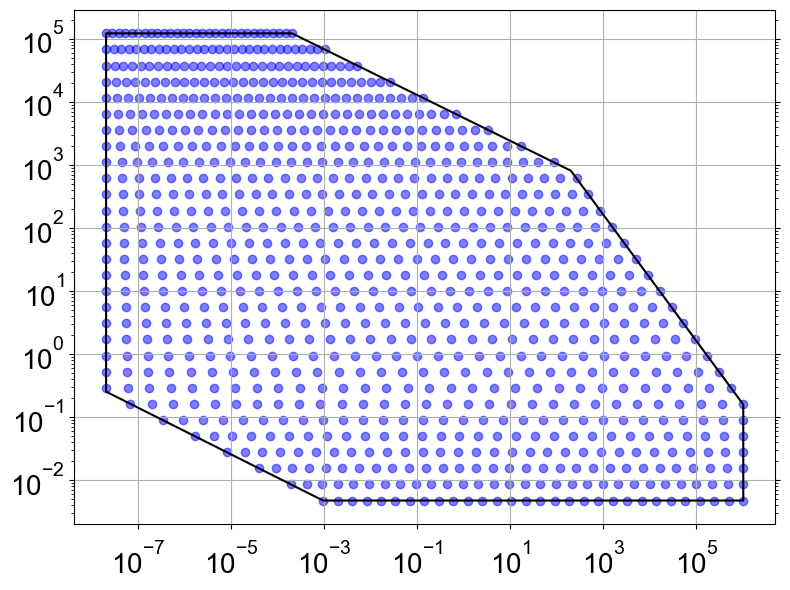

In [43]:
plt.figure(figsize=(8,6))

plt.plot(x_poly_model, y_poly_model, color='black')

plt.scatter(
    rho_range.ravel(),
    np.broadcast_to(Sigma_0_p_range, rho_range.shape).ravel(),
    marker='o',
    color='blue',
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.grid()

plt.show()

The next cell illustrates the full parameter space calculation. It is commented out because the subsequent analysis uses precomputed results from `data/precomputed_results`.

In [44]:
# sol_save = np.zeros((num_Sigma_0_p, num_rho, num_points - 1, 3))

# for j in tqdm(range(num_rho)):
#     x0 = None
    
#     for i in tqdm(range(num_Sigma_0_p)):
#         rho_cur, Sigma_0_p_cur = rho_range[j, i], Sigma_0_p_range[i]
        
#         model_params = {
#             'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
#             'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
#             'p_init_param': 5e-3,
#             'flag_one_way': 1,
#             'method': 'hybr'
#         }

#         # uncoupled
#         # model_params['eta'] = model_params['beta'] = 0

#         # one-way coupled
#         # model_params['flag_one_way'] = 0

#         # no cross-coupling
#         # model_params['eta'] = 0
        
#         solver = Solver(model_params, gc)
#         sol_cur = solver.solve(x0)

#         x0 = sol_cur['sol']
        
#         sol_save[i, j] = np.concatenate((
#             sol_cur['x_z'][:, None], 
#             sol_cur['w'][:, None], 
#             sol_cur['p'][:, None]
#         ), axis=1)

In [45]:
sol_fully_coupled = np.load(data_folder / 'fully_coupled.npy')
sol_uncoupled = np.load(data_folder / 'uncoupled.npy')
sol_one_way_coupled = np.load(data_folder / 'one_way_coupled.npy')
sol_no_cross_couplings = np.load(data_folder / 'no_cross_couplings.npy')

## Relative difference maps (Section 5.3.1)

In [46]:
reduced_models = {
    "uncoupled": sol_uncoupled,
    "one_way_coupled": sol_one_way_coupled,
    "no_cross_couplings": sol_no_cross_couplings,
}

x_cuts = {
    "1e-2": 1e-2, "1e-1": 1e-1, "1e0": 1.0,
    "1e1": 10.0, "1e2": 100.0, "inf": np.inf,
}

rho_grid = rho_range.T
sigma_grid = np.broadcast_to(Sigma_0_p_range[:, None], rho_grid.shape)

log_rho_ref = np.log10(rho_range_l_mk)
log_sigma_ref = np.log10(Sigma_0_p_range_l_mk)
l_mk_grid = np.empty(rho_grid.shape)

for i, j in np.ndindex(rho_grid.shape):
    dist2 = (
        (log_rho_ref - np.log10(rho_grid[i, j]))**2
        + (log_sigma_ref - np.log10(Sigma_0_p_range[i]))**2
    )
    l_mk_grid[i, j] = l_mk_rocks_mean[np.argmin(dist2)]

xi = sol_fully_coupled[..., 0]
masks = {
    key: np.isfinite(xi) & (xi > 0) & (xi <= distance / l_mk_grid[..., None])
    for key, distance in x_cuts.items()
}

uncoupled_inf_min_errors = 100.0 * np.array([
    abs(1.0 - (1.0 - beta_cur)**(-1/3)),
    abs(1.0 - (1.0 - beta_cur)**(2/3)),
])

sol_dif = {}

for model_name, reduced in reduced_models.items():
    with np.errstate(divide="ignore", invalid="ignore"):
        relative_error = 100.0 * np.abs(
            (sol_fully_coupled[..., 1:3] - reduced[..., 1:3])
            / sol_fully_coupled[..., 1:3]
        )

    sol_dif[model_name] = {}

    for cut_key, mask in masks.items():
        max_error = np.max(
            relative_error, axis=2,
            where=mask[..., None], initial=-np.inf,
        )
        max_error[~mask.any(axis=2)] = np.nan

        if model_name == "uncoupled" and np.isinf(x_cuts[cut_key]):
            max_error = np.maximum(max_error, uncoupled_inf_min_errors)

        sol_dif[model_name][cut_key] = {
            "delta_w": max_error[..., 0],
            "delta_p": max_error[..., 1],
        }

In [47]:
threshold = 5.0
metrics = ("combined", "delta_w")
method = "cubic"
n_interp = 400

x, y = rho_grid.ravel(), sigma_grid.ravel()
points = np.column_stack((np.log10(x), np.log10(y)))

XI, YI = np.meshgrid(
    np.geomspace(x.min(), x.max(), n_interp),
    np.geomspace(y.min(), y.max(), n_interp),
)
XIlog, YIlog = np.log10(XI), np.log10(YI)

polygon = np.column_stack((x_poly_model, y_poly_model))
inside_model = Path_plt(np.log10(polygon)).contains_points(
    np.column_stack((XIlog.ravel(), YIlog.ravel())), radius=1e-12,
).reshape(XI.shape)

Relative difference $\Delta = \mathrm{max}(\Delta_\Omega, \Delta_\Pi)$ between the fully coupled and a reduced model (uncoupled, one-way coupled, model without cross-couplings).

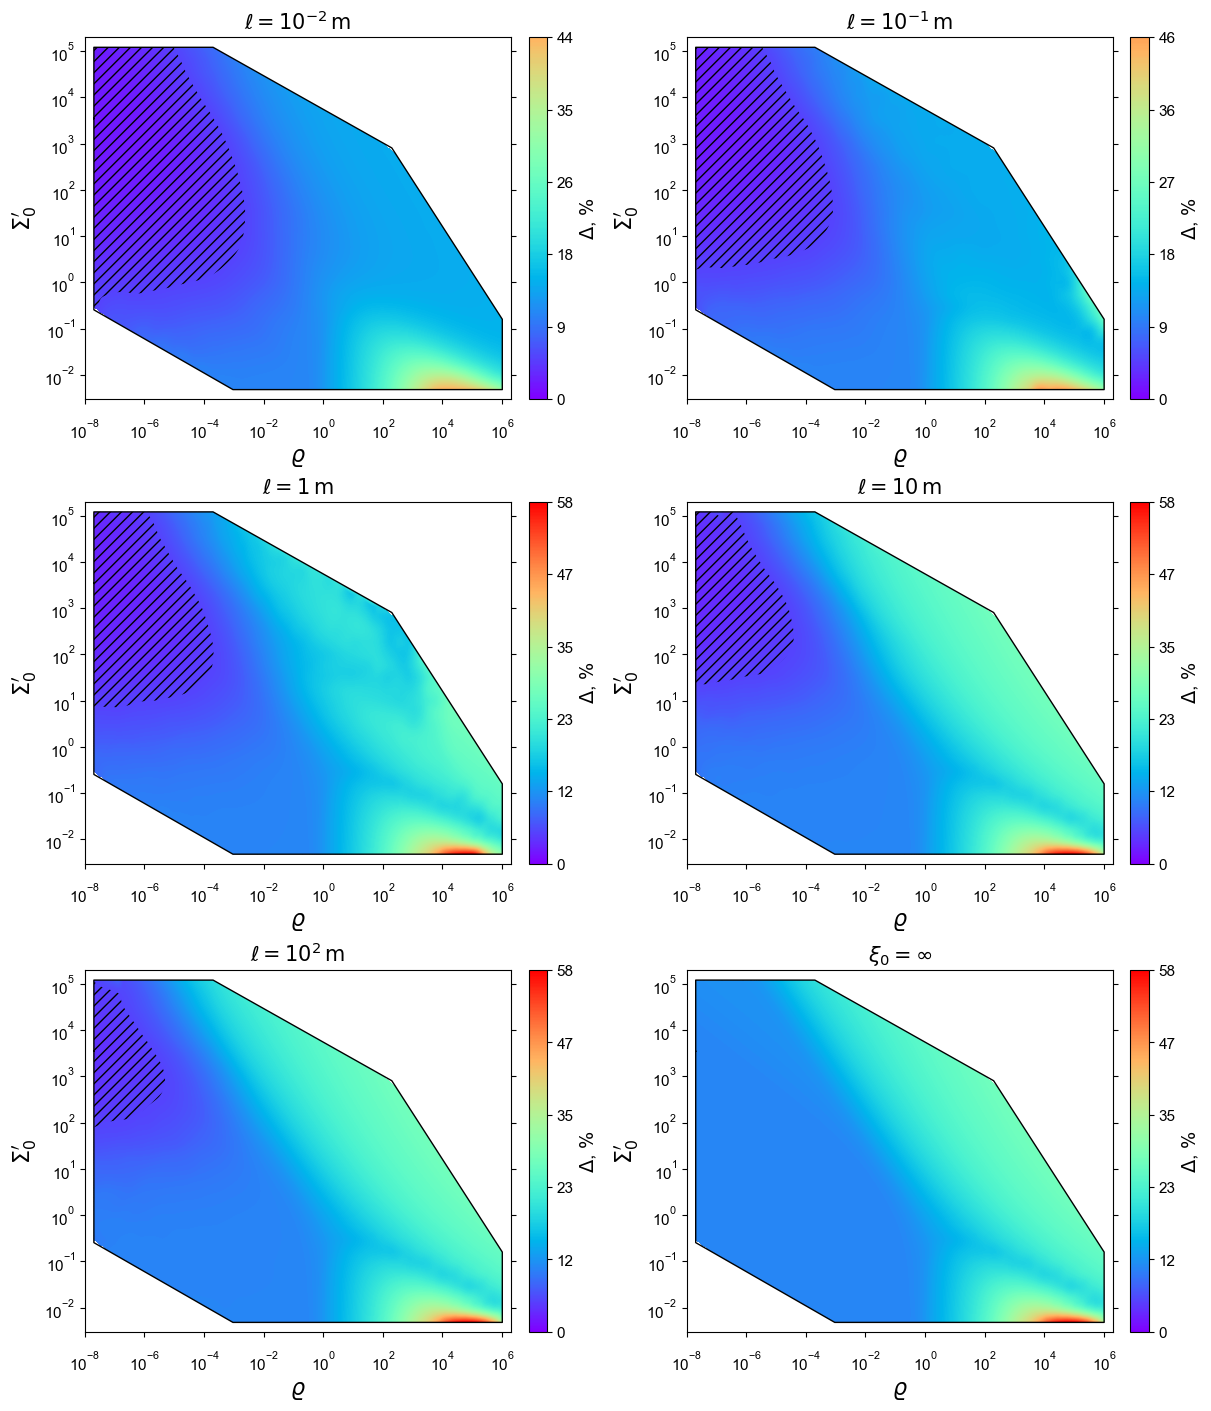

In [48]:
model_name = 'uncoupled'
# model_name = 'one_way_coupled'
# model_name = 'no_cross_couplings'

fig, axes = plot_relative_differences(
    sol_dif, model_name, points, XI, YI, polygon,
    metric="combined", x_cuts=x_cuts,
    threshold=threshold, method=method,
)
plt.show()

Relative difference $\Delta_\Omega$ between the fully coupled and a reduce model (uncoupled, one-way coupled, model without cross-couplings).

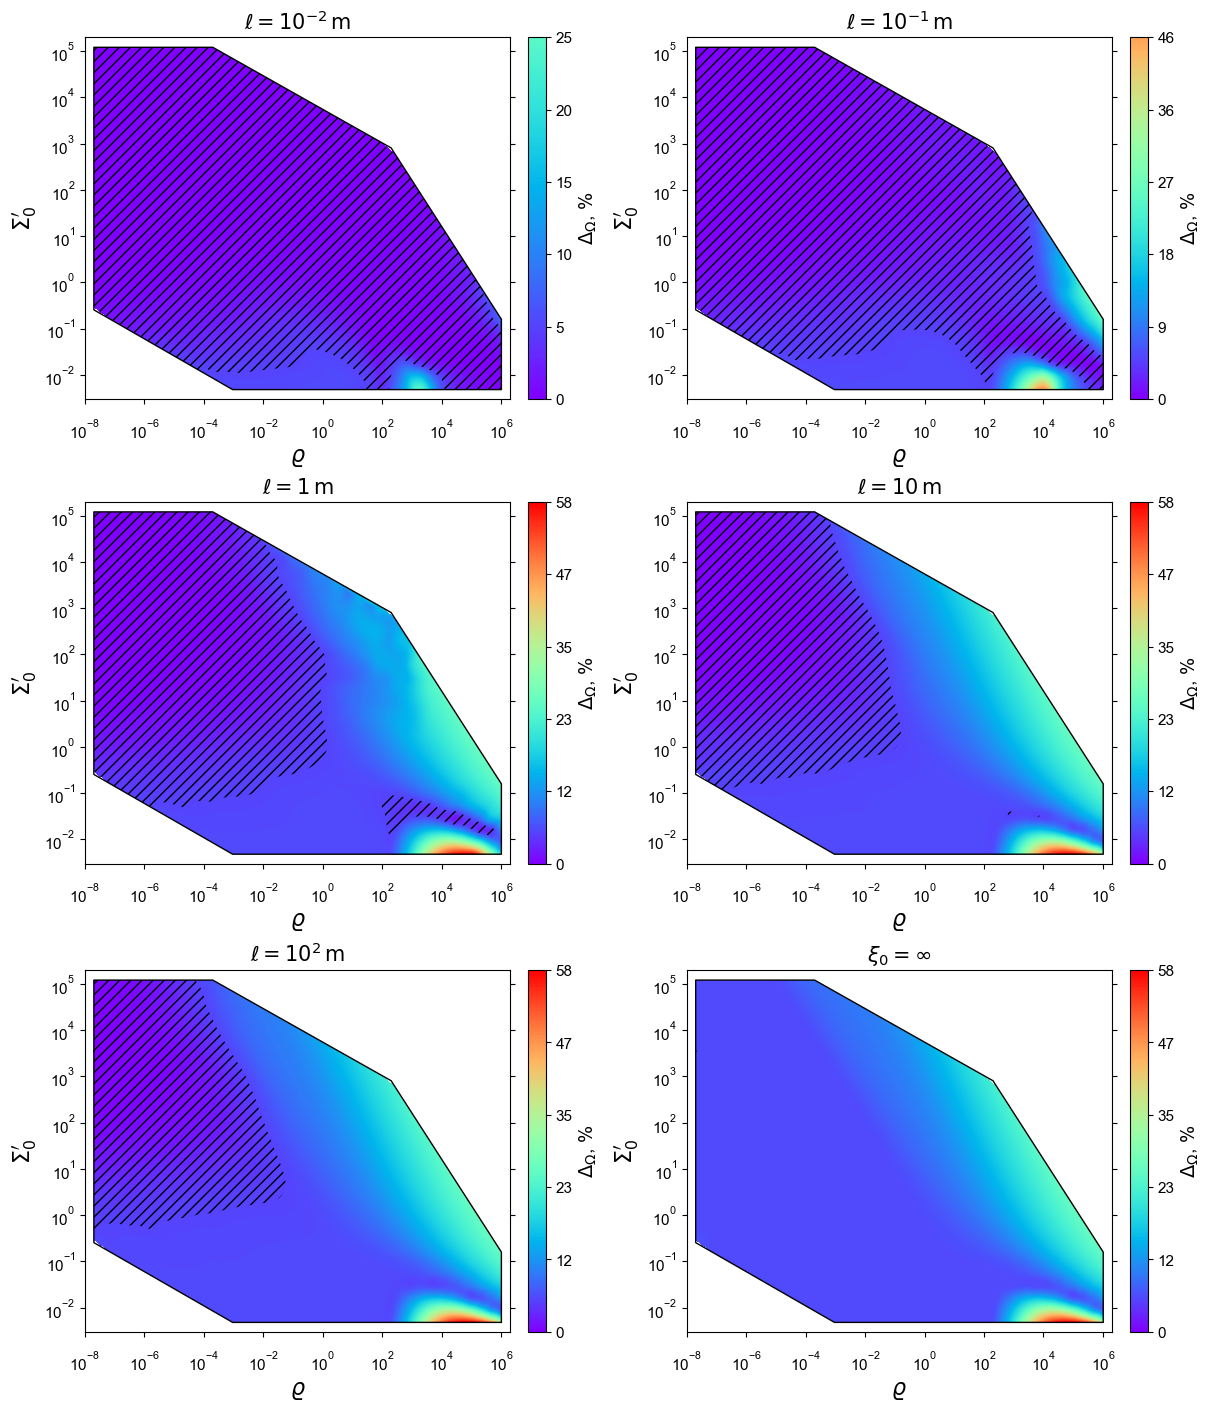

In [49]:
model_name = 'uncoupled'
# model_name = 'one_way_coupled'
# model_name = 'no_cross_couplings'

fig, axes = plot_relative_differences(
    sol_dif, model_name, points, XI, YI, polygon,
    metric="delta_w", x_cuts=x_cuts,
    threshold=threshold, method=method,
)
plt.show()

## Regime maps (Section 5.3.2 and Appendix E)

In [50]:
domain_models = {
    "D0": "uncoupled",
    "D1": "no_cross_couplings",
    "D2": "one_way_coupled",
}

domain_maps = {}

for metric in metrics:
    domain_maps[metric] = {}

    for cut_key in x_cuts:
        values = {}

        for domain, model_name in domain_models.items():
            errors = sol_dif[model_name][cut_key]
            z = (np.maximum(errors["delta_w"], errors["delta_p"])
                 if metric == "combined" else errors[metric])
            values[domain] = z.ravel()

        valid = np.logical_and.reduce([
            np.isfinite(z) for z in values.values()
        ])

        interpolated = {}

        for domain, z in values.items():
            ZI = griddata(
                points[valid], z[valid], (XIlog, YIlog), method=method,
            )
            interpolated[domain] = np.clip(
                ZI, z[valid].min(), z[valid].max(),
            )

        D3 = inside_model & np.logical_and.reduce([
            np.isfinite(ZI) for ZI in interpolated.values()
        ])

        entry = {
            domain: (ZI < threshold) & D3
            for domain, ZI in interpolated.items()
        }
        entry["D3"] = D3
        domain_maps[metric][cut_key] = entry

In [51]:
regime_maps = {}

for metric, by_cut in domain_maps.items():
    regime_maps[metric] = {}

    for cut_key, entry in by_cut.items():
        D0, D1, D2, D3 = (entry[f"D{i}"] for i in range(4))

        regime_maps[metric][cut_key] = {
            "R0": D0 & D1 & D2,
            "R1": D1 & D2 & ~D0,
            "R2": D2 & ~D1,
            "R3": D3 & ~D2,
        }

Regime map corresponding to the combined metric $\Delta = \mathrm{max}(\Delta_\Omega, \Delta_\Pi)$.

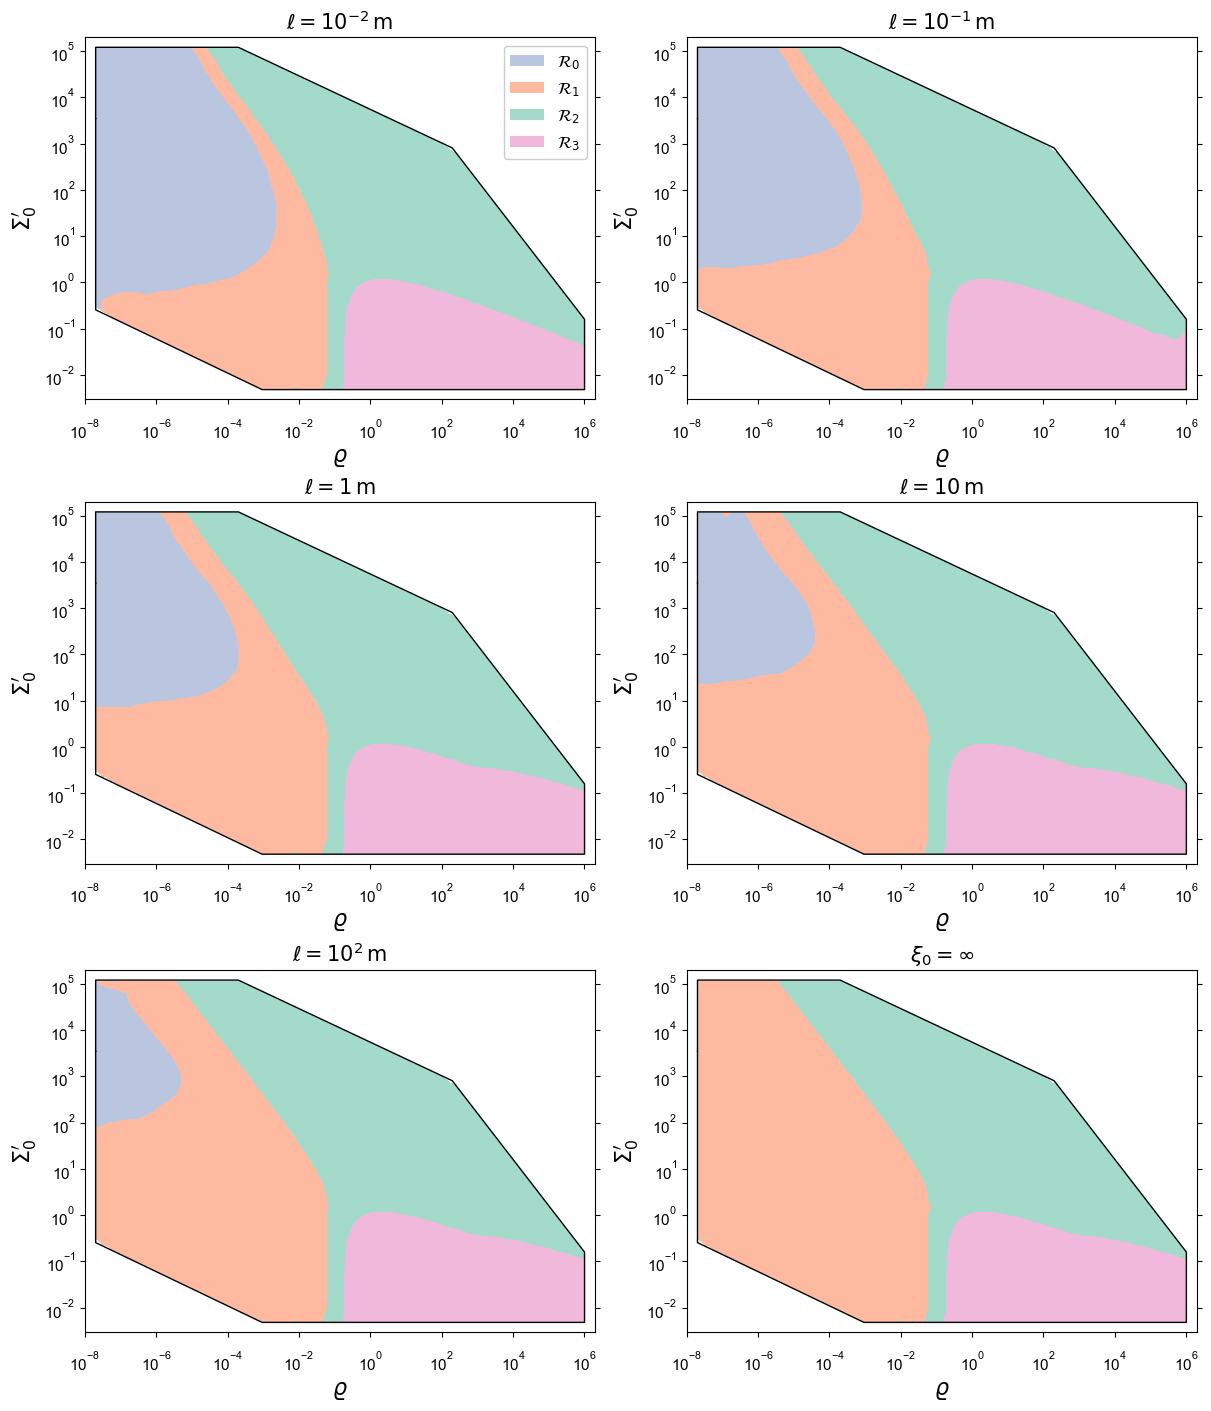

In [52]:
fig, axes = plot_regime_maps(
    regime_maps, XI, YI, polygon,
    metric='combined', x_cuts=x_cuts,
)
plt.show()

Regime maps based on the opening profiles (metric $\Delta_\Omega$).

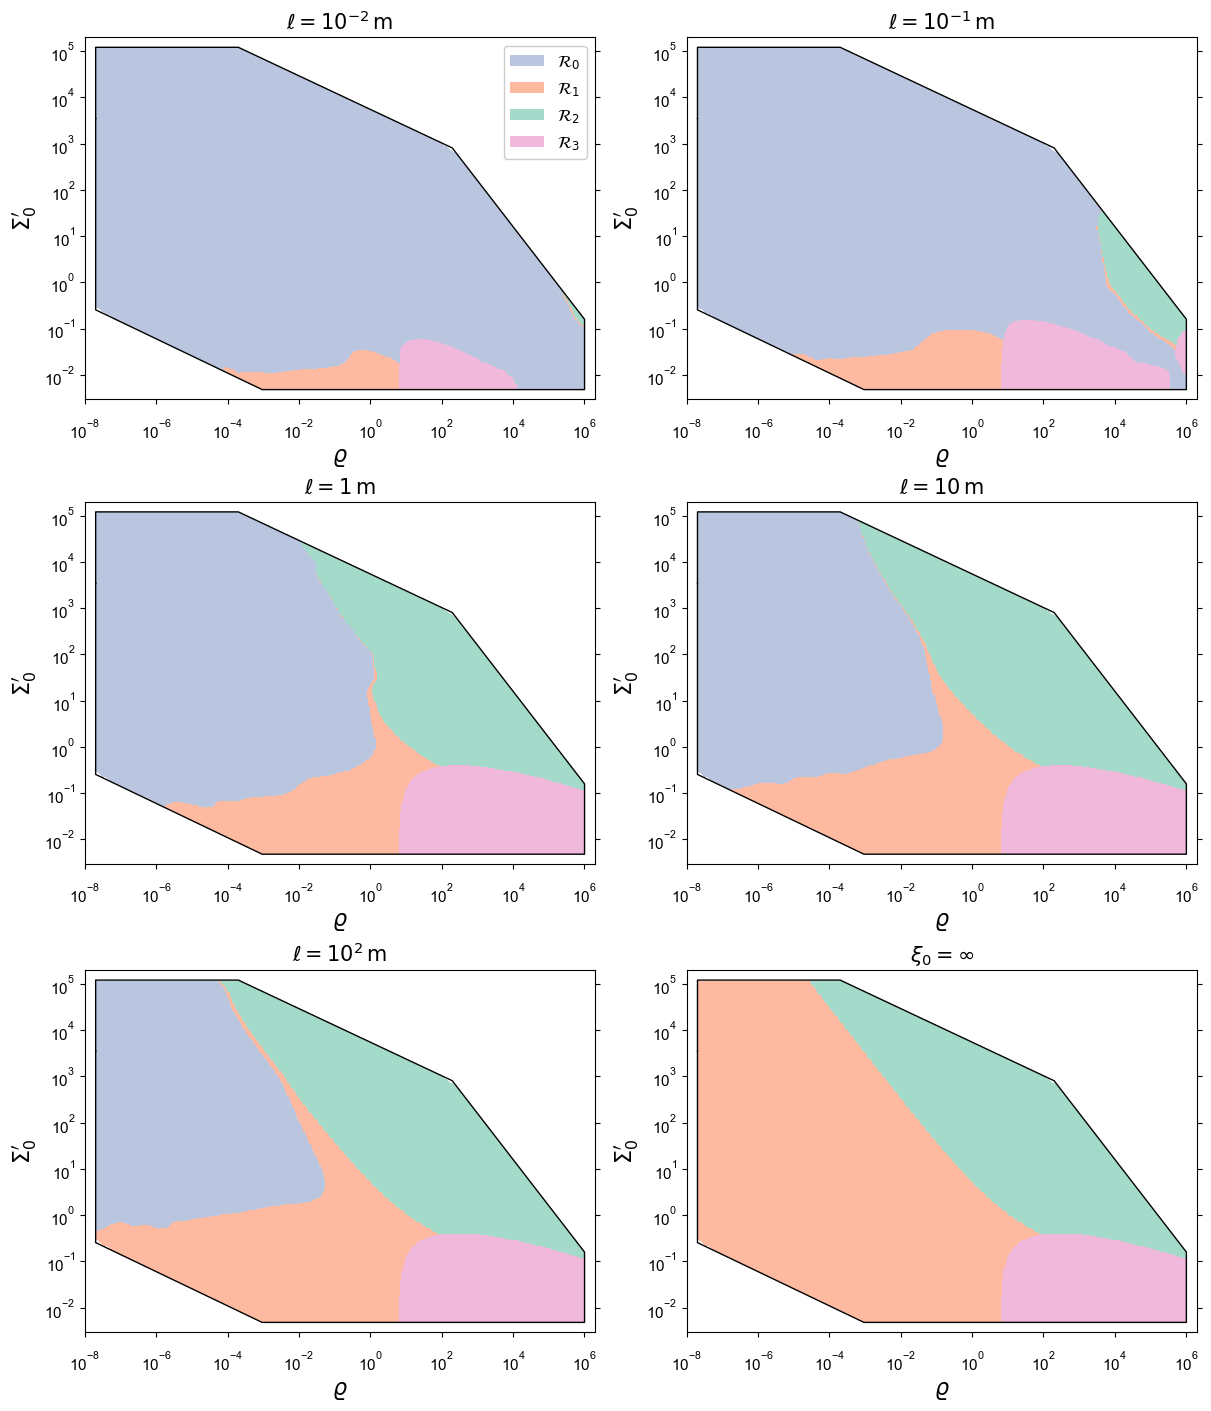

In [53]:
fig, axes = plot_regime_maps(
    regime_maps, XI, YI, polygon,
    metric='delta_w', x_cuts=x_cuts,
)
plt.show()

# Solution structure in characteristic coupling regimes (Section 5.4)

## Regimes 0 and 1: negligible poroelastic effects and dominance of the direct mechanical poroelastic response (Section 5.4.1)

In [54]:
rho_cur = 1e-5
Sigma_0_p_cur = 1e2
beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

p_init_param = 5e-3

model_params = {
    'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
    'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
    'p_init_param': p_init_param,
    'flag_one_way': 1,
    'method': 'hybr'
}

dist2 = (np.log10(rho_range_l_mk) - np.log10(rho_cur)) ** 2 + (np.log10(Sigma_0_p_range_l_mk) - np.log10(Sigma_0_p_cur)) ** 2

# -------------------------------------------------------------------------
# fully coupled
# -------------------------------------------------------------------------

solver = Solver(model_params, gc)
sol_fully_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# one-way coupled (2D PDL)
# -------------------------------------------------------------------------

model_params['flag_one_way'] = 0
solver = Solver(model_params, gc)
sol_one_way_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# uncoupled (2D PDL)
# -------------------------------------------------------------------------

model_params['eta'] = model_params['beta'] = 0
solver = Solver(model_params, gc)
sol_uncoupled = solver.solve(None)

Solver converged successfully
Residual norm: 4.01e-05
Solver converged successfully
Residual norm: 1.59e-04
Solver converged successfully
Residual norm: 5.75e-05


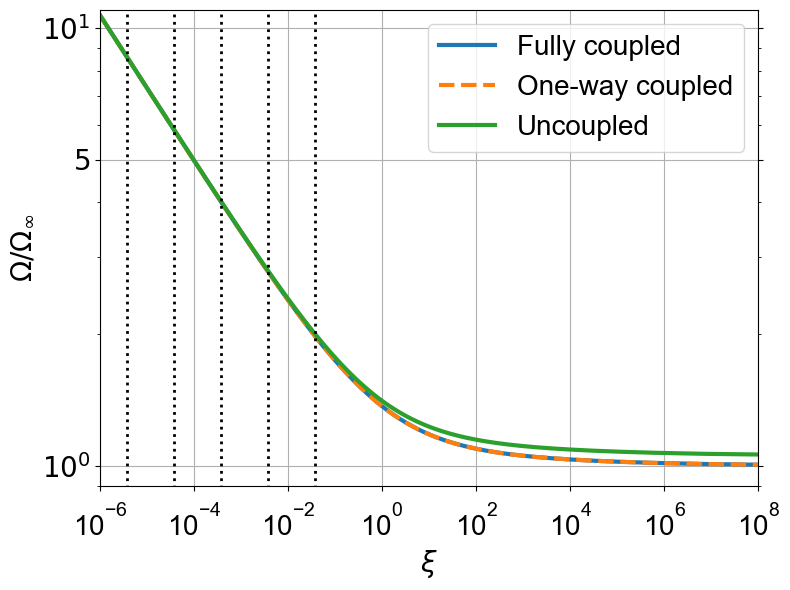

In [55]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, w_cur = sol_fully_coupled['x_z'], sol_fully_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, w_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, w_cur = sol_uncoupled['x_z'], sol_uncoupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-6, 1e8)
plt.ylim(0.9, 11)

plt.legend(fontsize=20)

ax = plt.gca()
ax.set_yticks([1, 5, 10])
ax.set_yticklabels([r'$10^0$',r'$5$', r'$10^1$'])

plt.grid()

plt.show()

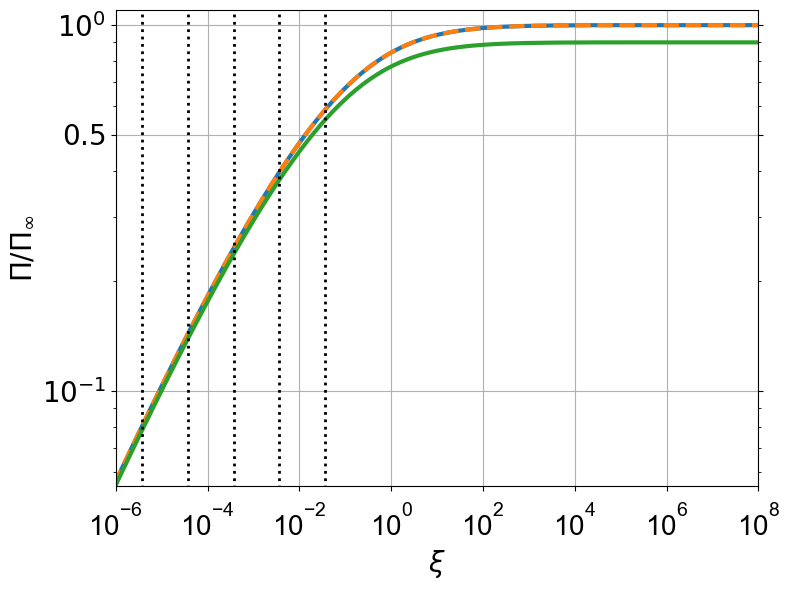

In [56]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, p_cur = sol_fully_coupled['x_z'], sol_fully_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, p_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, p_cur = sol_uncoupled['x_z'], sol_uncoupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-6, 1e8)
plt.ylim(5.5e-2, 1.1)

ax = plt.gca()
ax.set_yticks([0.1, 0.5, 1])
ax.set_yticklabels([r'$10^{-1}$', r'$0.5$', r'$10^0$'])

plt.grid()

plt.show()

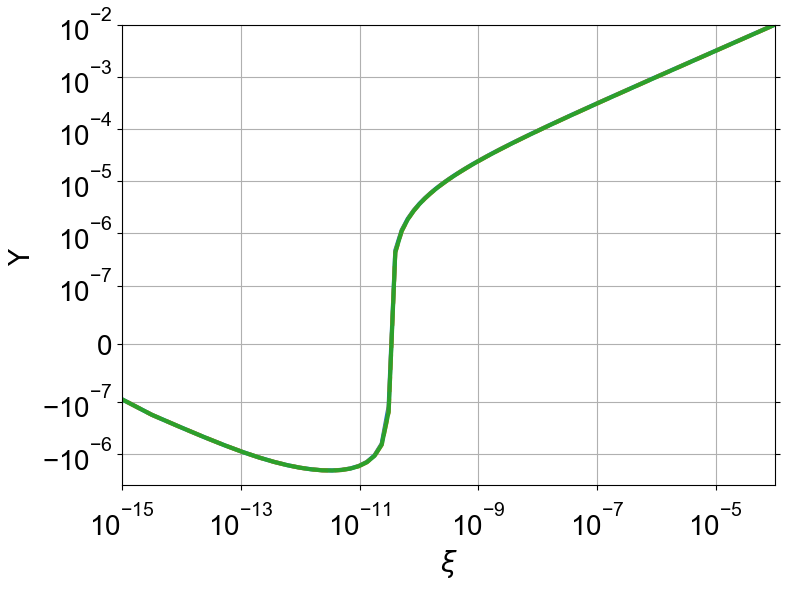

In [57]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, v_cur = sol_fully_coupled['x_z'], sol_fully_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, v_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, v_cur = sol_uncoupled['x_z'], sol_uncoupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Uncoupled')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xscale('log')
plt.yscale("symlog", linthresh=1e-7)

plt.xlim(1e-15, 1e-4)
plt.ylim(-4e-6, 1e-2)

plt.grid()

plt.show()

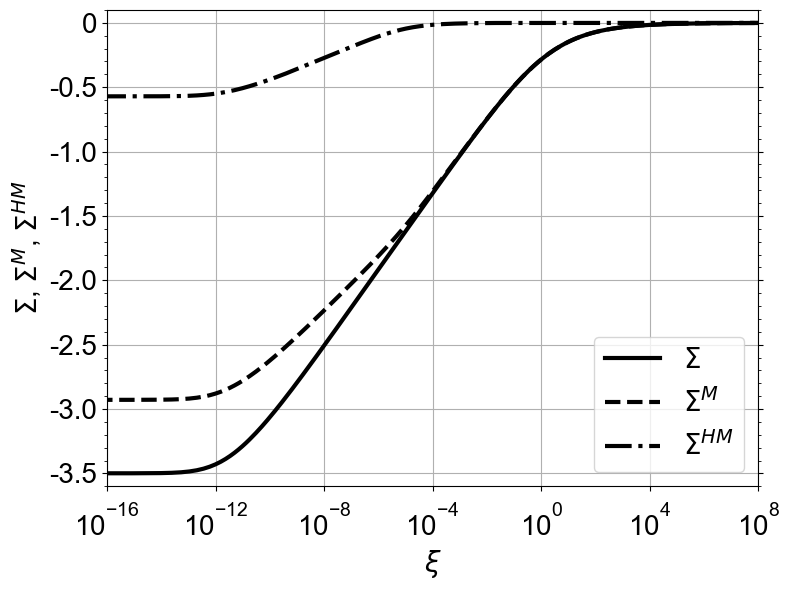

In [58]:
plt.figure(figsize=(8,6))

x_cur, sigma_M, sigma_HM = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['sigma_M'], \
                            sol_fully_coupled['integrals']['sigma_HM']
plt.plot(x_cur, sigma_M + sigma_HM, linewidth=3, color='black', label=r'$\Sigma$')
plt.plot(x_cur, sigma_M, linewidth=3, color='black', linestyle='--', label=r'$\Sigma^M$')
plt.plot(x_cur, sigma_HM, linewidth=3, color='black', linestyle='-.', label=r'$\Sigma^{HM}$')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Sigma$, $\Sigma^M$, $\Sigma^{HM}$', fontsize=20)

plt.xscale('log')

plt.legend(fontsize=20)

plt.xlim(1e-16, 1e8)
plt.ylim(-3.6, 0.1)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.1f}')
)

plt.grid()

plt.show()

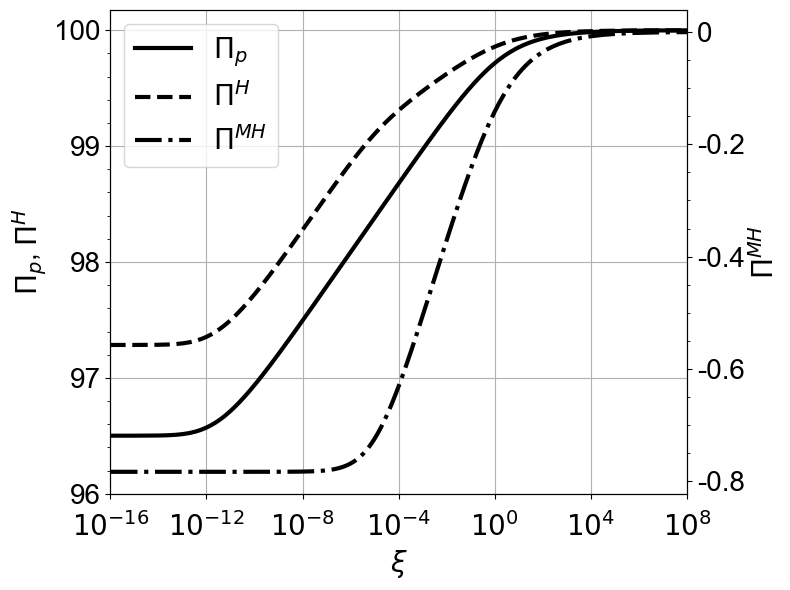

In [59]:
fig, ax1 = plt.subplots(figsize=(8, 6))

x_cur, p_H, p_MH = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['p_H'], sol_fully_coupled['integrals']['p_MH']

ax1.plot(x_cur, p_H + Sigma_0_p_cur + p_MH, linewidth=3,color='black',label=r'$\Pi_p$')

ax1.plot(x_cur, p_H + Sigma_0_p_cur, linewidth=3, color='black',linestyle='--', label=r'$\Pi^H$')

ax1.set_xlabel(r'$\xi$', fontsize=20)
# plt.xlabel(r'$x/\ell_{mk}$', fontsize=20)
ax1.set_ylabel(r'$\Pi_p$, $\Pi^H$', fontsize=20)

ax1.set_xscale('log')
ax1.set_xlim(1e-16, 1e8)
ax1.set_ylim(96, )

ax1.set_xticks(np.logspace(-16, 8, 7))
ax1.set_xticklabels([r'$10^{-16}$', r'$10^{-12}$', r'$10^{-8}$', r'$10^{-4}$', r'$10^{0}$', r'$10^{4}$', r'$10^8$'], fontsize=20)

ax2 = ax1.twinx()

ax2.plot(x_cur, p_MH, linewidth=3, color='black', linestyle='-.',label=r'$\Pi^{MH}$')

ax2.set_ylabel(r'$\Pi^{MH}$', fontsize=20, color='black')
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=20, loc='best')

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.1f}')
)
ax1.grid(True)

plt.show()

## Regime 2: significant influence of poroelastic backstress (Section 5.4.2)

In [60]:
rho_cur = 1e3
Sigma_0_p_cur = 10
beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

p_init_param = 5e-3

model_params = {
    'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
    'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
    'p_init_param': p_init_param,
    'flag_one_way': 1,
    'method': 'hybr'
}

dist2 = (np.log10(rho_range_l_mk) - np.log10(rho_cur)) ** 2 + (np.log10(Sigma_0_p_range_l_mk) - np.log10(Sigma_0_p_cur)) ** 2

# -------------------------------------------------------------------------
# fully coupled
# -------------------------------------------------------------------------

solver = Solver(model_params, gc)
sol_fully_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# one-way coupled (2D PDL)
# -------------------------------------------------------------------------

model_params['flag_one_way'] = 0
solver = Solver(model_params, gc)
sol_one_way_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# uncoupled (2D PDL)
# -------------------------------------------------------------------------

model_params['eta'] = model_params['beta'] = 0
solver = Solver(model_params, gc)
sol_uncoupled = solver.solve(None)

Solver converged successfully
Residual norm: 3.37e-06
Solver converged successfully
Residual norm: 1.56e-06
Solver converged successfully
Residual norm: 1.10e-07


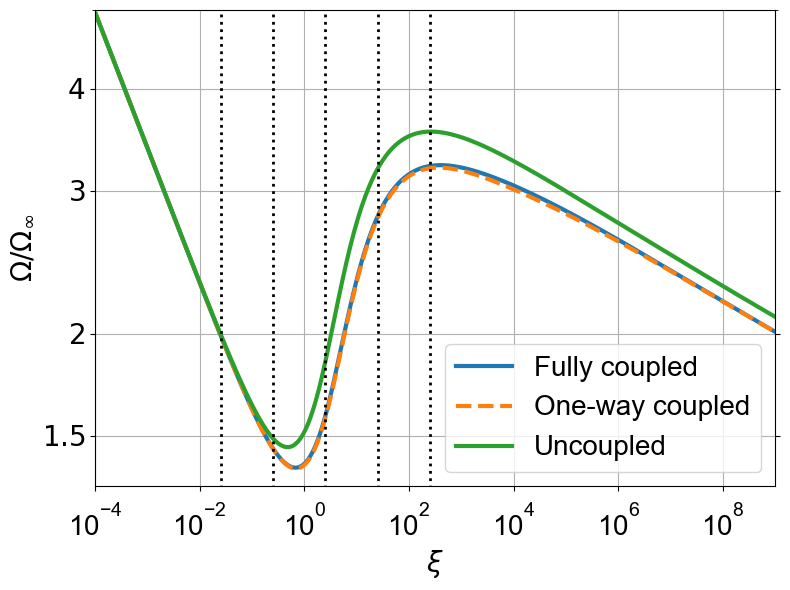

In [61]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, w_cur = sol_fully_coupled['x_z'], sol_fully_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, w_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, w_cur = sol_uncoupled['x_z'], sol_uncoupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-4, 1e9)
plt.ylim(1.3, 5)

plt.legend(fontsize=20)

ax = plt.gca()
ax.set_yticks([1.5, 2, 3, 4])
ax.set_yticklabels([r'$1.5$',r'$2$', r'$3$', r'$4$'])

plt.grid()

plt.show()

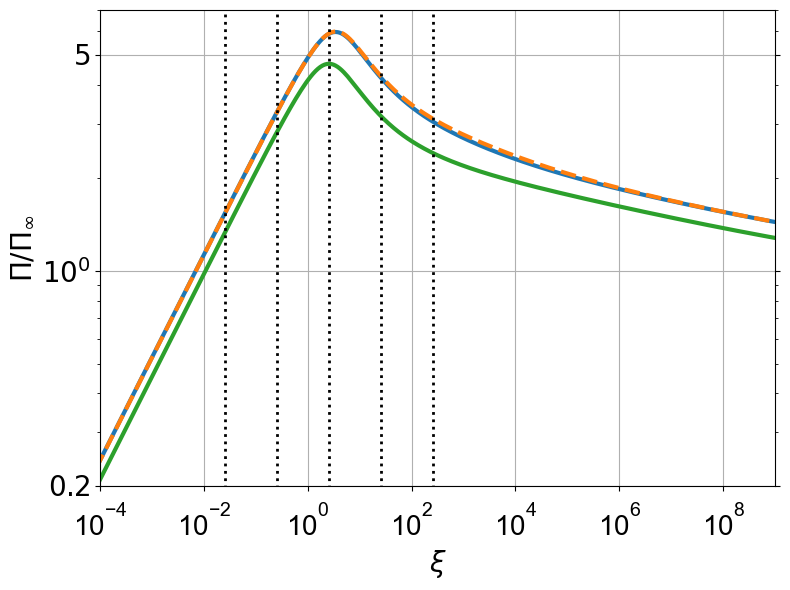

In [62]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, p_cur = sol_fully_coupled['x_z'], sol_fully_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, p_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, p_cur = sol_uncoupled['x_z'], sol_uncoupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-4, 1e9)
plt.ylim(2e-1, 7)

ax = plt.gca()
ax.set_yticks([0.2, 1, 5])
ax.set_yticklabels([r'$0.2$',r'$10^0$', r'$5$'])

plt.grid()

plt.show()

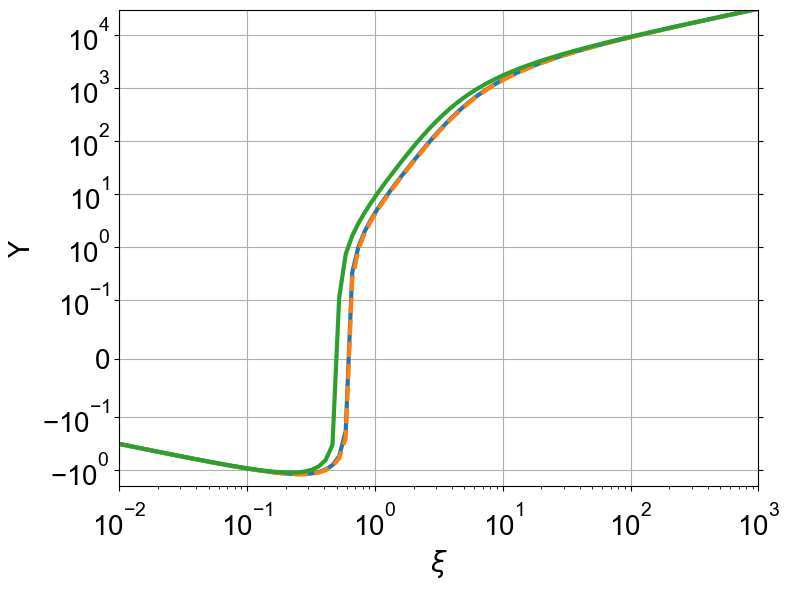

In [63]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, v_cur = sol_fully_coupled['x_z'], sol_fully_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, v_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, v_cur = sol_uncoupled['x_z'], sol_uncoupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Uncoupled')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xscale('log')
plt.yscale("symlog", linthresh=1e-1)

plt.xlim(1e-2, 1e3)
plt.ylim(-2, 3e4)

plt.grid()

plt.show()

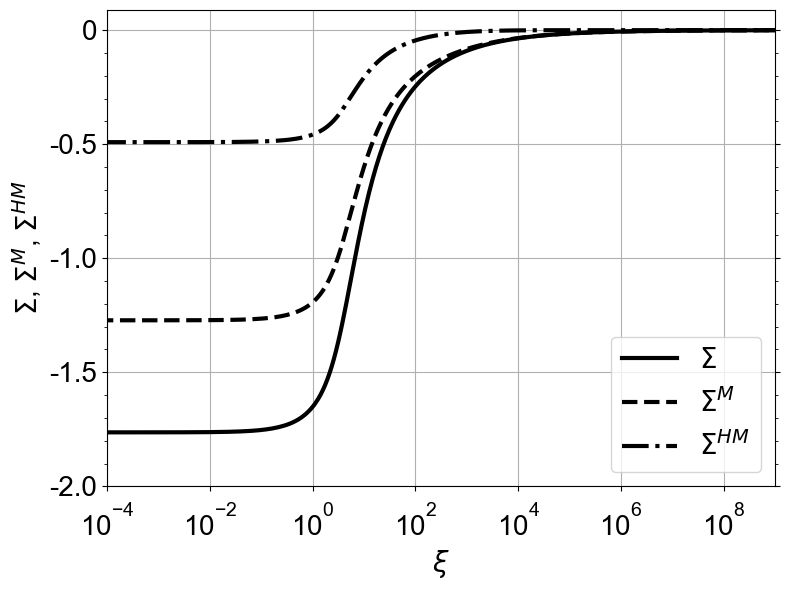

In [64]:
plt.figure(figsize=(8,6))

x_cur, sigma_M, sigma_HM = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['sigma_M'], \
                            sol_fully_coupled['integrals']['sigma_HM']
plt.plot(x_cur, sigma_M + sigma_HM, linewidth=3, color='black', label=r'$\Sigma$')
plt.plot(x_cur, sigma_M, linewidth=3, color='black', linestyle='--', label=r'$\Sigma^M$')
plt.plot(x_cur, sigma_HM, linewidth=3, color='black', linestyle='-.', label=r'$\Sigma^{HM}$')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Sigma$, $\Sigma^M$, $\Sigma^{HM}$', fontsize=20)

plt.xscale('log')

plt.legend(fontsize=20)

plt.xlim(1e-4, 1e9)
plt.ylim(-2, )

ax = plt.gca()
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.1f}')
)

plt.grid()

plt.show()

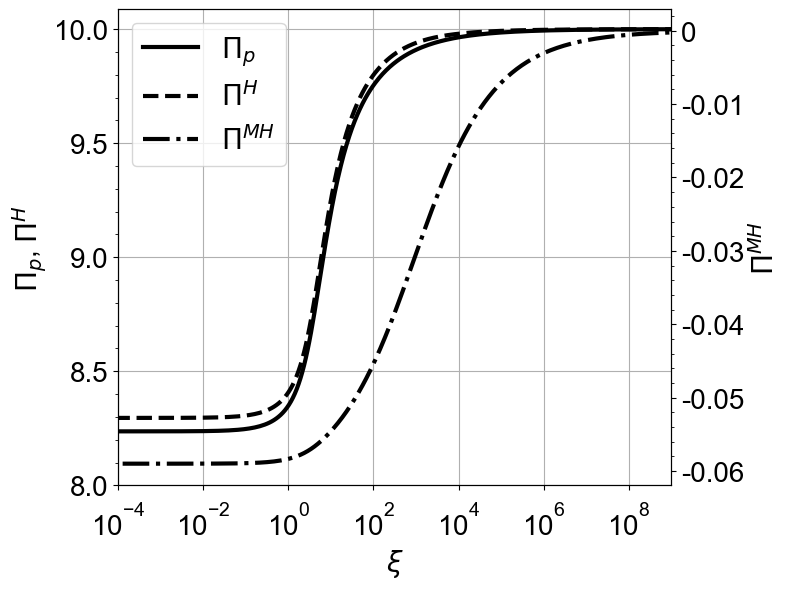

In [65]:
fig, ax1 = plt.subplots(figsize=(8, 6))

x_cur, p_H, p_MH = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['p_H'], sol_fully_coupled['integrals']['p_MH']

ax1.plot(x_cur, p_H + Sigma_0_p_cur + p_MH, linewidth=3,color='black',label=r'$\Pi_p$')

ax1.plot(x_cur, p_H + Sigma_0_p_cur, linewidth=3, color='black',linestyle='--', label=r'$\Pi^H$')

ax1.set_xlabel(r'$\xi$', fontsize=20)
# plt.xlabel(r'$x/\ell_{mk}$', fontsize=20)
ax1.set_ylabel(r'$\Pi_p$, $\Pi^H$', fontsize=20)

ax1.set_xscale('log')
ax1.set_xlim(1e-4, 1e9)
ax1.set_ylim(8, )

ax2 = ax1.twinx()

ax2.plot(x_cur, p_MH, linewidth=3, color='black', linestyle='-.',label=r'$\Pi^{MH}$')

ax2.set_ylabel(r'$\Pi^{MH}$', fontsize=20, color='black')
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=20, loc='best')

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.2f}')
)

ax1.grid()

plt.show()

## Regime 3: fully coupled regime (Section 5.4.3)

In [66]:
rho_cur = 1e4
Sigma_0_p_cur = 1e-2
beta_cur = 0.15
eta_cur = 0.3
S_cur = 2 * (1 - beta_cur) * eta_cur ** 2 / beta_cur

p_init_param = 5e-3

model_params = {
    'rho': rho_cur, 'Sigma_0_p': Sigma_0_p_cur, 
    'beta': beta_cur, 'eta': eta_cur, 'S': S_cur,
    'p_init_param': p_init_param,
    'flag_one_way': 1,
    'method': 'hybr'
}

dist2 = (np.log10(rho_range_l_mk) - np.log10(rho_cur)) ** 2 + (np.log10(Sigma_0_p_range_l_mk) - np.log10(Sigma_0_p_cur)) ** 2

# -------------------------------------------------------------------------
# fully coupled
# -------------------------------------------------------------------------

solver = Solver(model_params, gc)
sol_fully_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# one-way coupled (2D PDL)
# -------------------------------------------------------------------------

model_params['flag_one_way'] = 0
solver = Solver(model_params, gc)
sol_one_way_coupled = solver.solve(None)

# -------------------------------------------------------------------------
# uncoupled (2D PDL)
# -------------------------------------------------------------------------

model_params['eta'] = model_params['beta'] = 0
solver = Solver(model_params, gc)
sol_uncoupled = solver.solve(None)

Solver converged successfully
Residual norm: 1.39e-08
Solver converged successfully
Residual norm: 3.18e-08
Solver converged successfully
Residual norm: 7.26e-08


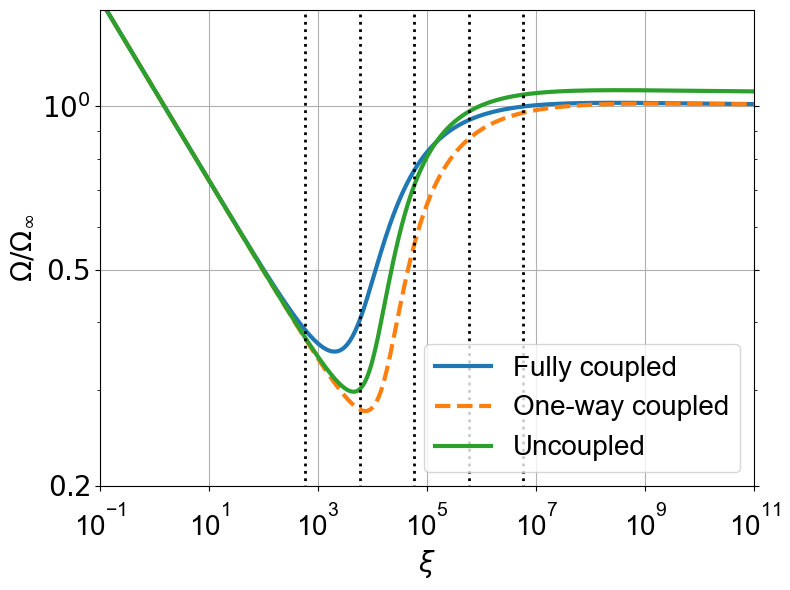

In [67]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, w_cur = sol_fully_coupled['x_z'], sol_fully_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, w_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, w_cur = sol_uncoupled['x_z'], sol_uncoupled['w']
coef_cur = far_field_opening(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_cur * w_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Omega/\Omega_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-1, 1e11)
plt.ylim(0.2, 1.5)

plt.legend(fontsize=20)

ax = plt.gca()
ax.set_yticks([0.2, 0.5, 1])
ax.set_yticklabels([r'$0.2$',r'$0.5$', r'$10^0$'])
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plt.grid()

plt.show()

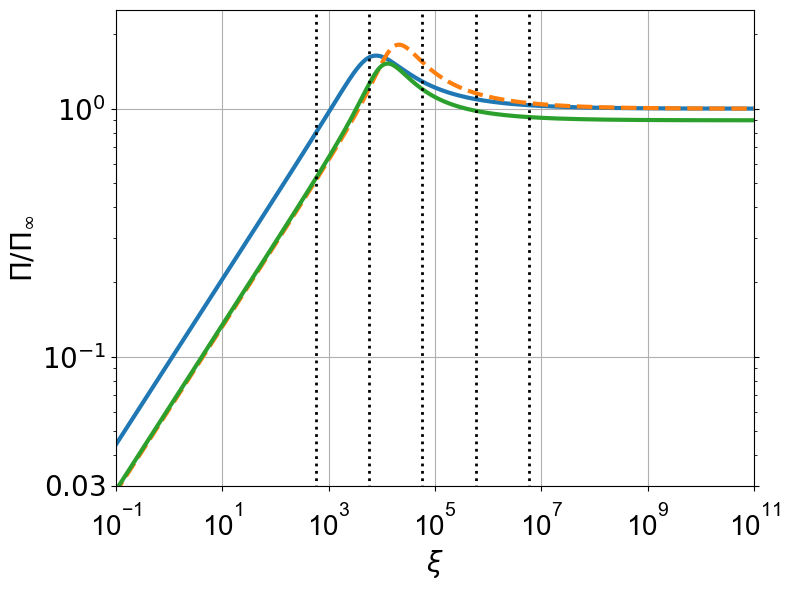

In [68]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, p_cur = sol_fully_coupled['x_z'], sol_fully_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, p_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, p_cur = sol_uncoupled['x_z'], sol_uncoupled['p']
coef_1 = far_field_pressure(x_cur, beta_cur) ** -1 
plt.plot(x_cur, coef_1 * p_cur, linewidth=3, label='Uncoupled', linestyle='-')

for x_dist in [0.01, 0.1, 1, 10, 100]:
    plt.plot([x_dist / l_mk_rocks_mean[np.argmin(dist2)]] * 2, [-100, 100], linestyle=':', color='black', linewidth=2)

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Pi/\Pi_{\infty}$', fontsize=20)

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e-1, 1e11)
plt.ylim(3e-2, 2.5)

ax = plt.gca()
ax.set_yticks([0.03, 0.1, 1])
ax.set_yticklabels([r'$0.03$', r'$10^{-1}$', r'$10^0$'])

plt.grid()

plt.show()

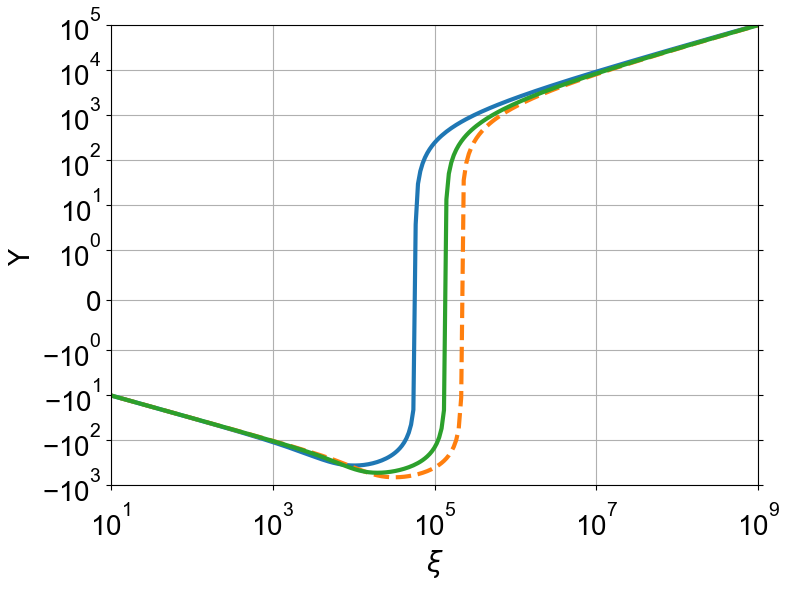

In [69]:
plt.figure(figsize=(8,6))

# fully coupled
x_cur, v_cur = sol_fully_coupled['x_z'], sol_fully_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Fully coupled')

# one-way coupled
x_cur, v_cur = sol_one_way_coupled['x_z'], sol_one_way_coupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='One-way coupled', linestyle='--')

# uncoupled
x_cur, v_cur = sol_uncoupled['x_z'], sol_uncoupled['v']
plt.plot(x_cur, v_cur, linewidth=3, label='Uncoupled')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Upsilon$', fontsize=20)

plt.xscale('log')
plt.yscale("symlog", linthresh=1e0)

plt.xlim(1e1, 1e9)
plt.ylim(-1e3, 1e5)

plt.grid()

plt.show()

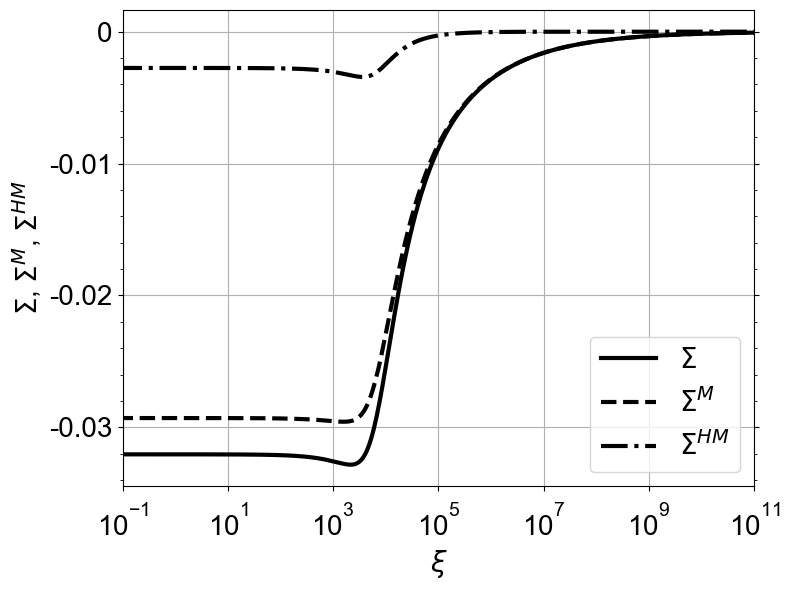

In [70]:
plt.figure(figsize=(8,6))

x_cur, sigma_M, sigma_HM = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['sigma_M'], \
                            sol_fully_coupled['integrals']['sigma_HM']
plt.plot(x_cur, sigma_M + sigma_HM, linewidth=3, color='black', label=r'$\Sigma$')
plt.plot(x_cur, sigma_M, linewidth=3, color='black', linestyle='--', label=r'$\Sigma^M$')
plt.plot(x_cur, sigma_HM, linewidth=3, color='black', linestyle='-.', label=r'$\Sigma^{HM}$')

plt.xlabel(r'$\xi$', fontsize=20)
plt.ylabel(r'$\Sigma$, $\Sigma^M$, $\Sigma^{HM}$', fontsize=20)

plt.xscale('log')

plt.legend(fontsize=20)

plt.xlim(1e-1, 1e11)

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.2f}')
)

plt.grid()

plt.show()

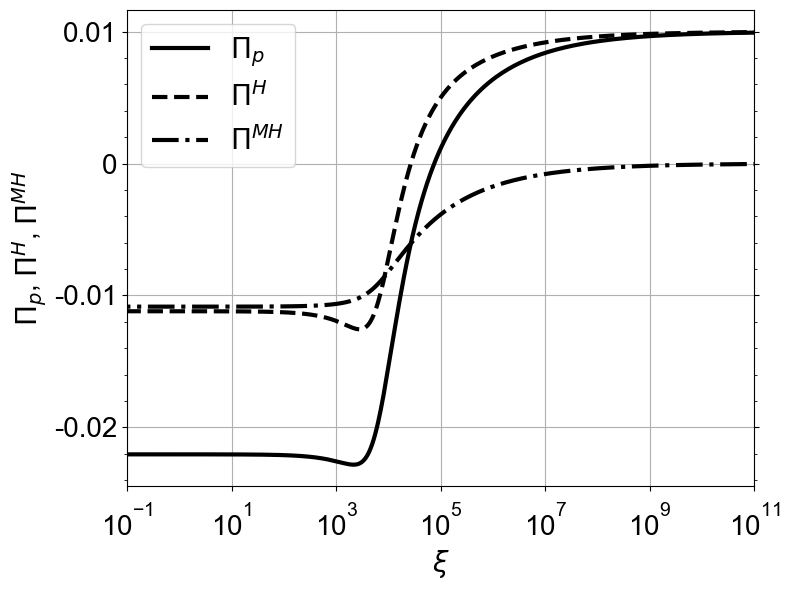

In [71]:
fig, ax1 = plt.subplots(figsize=(8, 6))

x_z_1, p_H, p_MH = sol_fully_coupled['x_z'], sol_fully_coupled['integrals']['p_H'], sol_fully_coupled['integrals']['p_MH']

ax1.plot(x_z_1, p_H + Sigma_0_p_cur + p_MH, linewidth=3,color='black',label=r'$\Pi_p$')

ax1.plot(x_z_1, p_H + Sigma_0_p_cur, linewidth=3, color='black',linestyle='--', label=r'$\Pi^H$')

ax1.plot(x_z_1, p_MH, linewidth=3, color='black', linestyle='-.',label=r'$\Pi^{MH}$')

ax1.set_xlabel(r'$\xi$', fontsize=20)
ax1.set_ylabel(r'$\Pi_p$, $\Pi^H$, $\Pi^{MH}$', fontsize=20)

ax1.set_xscale('log')
ax1.set_xlim(1e-1, 1e11)

ax1.legend(fontsize=20, loc='best')

ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '0' if abs(y) < 1e-12 else f'{y:.2f}')
)

ax1.grid()

plt.show()